In [1]:
import torch.nn.functional as F
from typing import List, Tuple
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import math
from torch.utils.data import DataLoader, TensorDataset, random_split
import pandas as pd
from sklearn.metrics import r2_score

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Helper Function

In [2]:
def plot_output(data,generated):
    """
    Visualize the training progress
    """
    plt.figure(figsize=(12, 6))
    for i, label in enumerate(['x']):
        plt.subplot(3, 1, i+1)
        plt.plot(data[0,:, i], label=f'True {label}')
        plt.plot(generated[:, i], label=f'Predicted {label}')
        plt.legend()
        plt.ylabel(label)
    plt.xlabel('Time Steps')
    plt.suptitle('Sample True vs Predicted')
    plt.show()

## Prepare the dataset

In [3]:
def load_and_prepare_signals(filename, timesteps):
    """
    Loads scalar X and Y data from CSV and converts them into time-series signals 
    required for SNN simulation (Shape: Samples, T, 1).
    """
    print(f"Loading data from '{filename}'...")
    
    try:
        df = pd.read_csv(filename)
        X_scalars = df['X_Input'].values.astype(np.float32)
        Y_scalars = df['Y_Target'].values.astype(np.float32)
    except FileNotFoundError:
        print(f"Error: The file '{filename}' was not found.")
        print("Please ensure the previous step to generate and save 'snn_simple_xy_data.csv' was executed.")
        raise
    
    X_scalars_r = X_scalars[:, np.newaxis]
    Y_scalars_r = Y_scalars[:, np.newaxis]

    X_signal_np = np.repeat(X_scalars_r, timesteps, axis=1)

    Y_supervisor_np = np.repeat(Y_scalars_r, timesteps, axis=1)

    X_signal = torch.from_numpy(X_signal_np[:, :, np.newaxis])
    Y_supervisor = torch.from_numpy(Y_supervisor_np[:, :, np.newaxis])

    print("Data loading and signal conversion complete.")
    print(f"Final Input Tensor Shape: {X_signal.shape}")
    return X_signal, Y_supervisor

def create_dataloaders(X_signal, Y_supervisor, batch_size, test_ratio):
    """
    Splits the data into training/testing sets and wraps them in PyTorch DataLoaders.
    """

    full_dataset = TensorDataset(X_signal, Y_supervisor)
    
    total_samples = len(full_dataset)
    test_size = int(test_ratio * total_samples)
    train_size = total_samples - test_size

    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print("-" * 50)
    print(f"Data Splitting and DataLoader creation complete.")
    print(f"  Training Samples: {len(train_dataset)}")
    print(f"  Testing Samples:  {len(test_dataset)}")
    print(f"  Train Loader Batches: {len(train_dataloader)}")
    print(f"  Test Loader Batches:  {len(test_dataloader)}")
    
    return train_dataloader, test_dataloader, train_dataset, test_dataset

def visualize_signals(X_signal, Y_supervisor, time_units, sample_indices):
    """Plots the constant input and target signals for selected samples."""
    
    fig, axes = plt.subplots(len(sample_indices), 1, figsize=(10, 3 * len(sample_indices)))
    
    if len(sample_indices) == 1:
        axes = [axes]
        
    fig.suptitle(f"SNN Signals for Regression (T={T}, dt={dt})", fontsize=14)

    for i, idx in enumerate(sample_indices):
        ax = axes[i]
        x_val = X_signal[idx, 0, 0].item()
        y_val = Y_supervisor[idx, 0, 0].item()
        
        ax.plot(time_units, X_signal[idx, :, 0].numpy(), 
                label=f'Input X: x = {x_val:.3f}', color='#1f77b4', linewidth=2)
        
        ax.plot(time_units, Y_supervisor[idx, :, 0].numpy(), 
                label=f'Target Y: x² = {y_val:.3f}', color='#ff7f0e', linestyle='--', linewidth=2)
        
        ax.set_ylabel(f'Value (Sample {idx})')
        ax.legend(loc='upper right')
        ax.grid(True, linestyle=':', alpha=0.6)

    axes[-1].set_xlabel(f'Time (units, Total Duration: {T * dt:.1f})')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Loading data from 'regression_data.csv'...
Data loading and signal conversion complete.
Final Input Tensor Shape: torch.Size([5000, 5000, 1])
--------------------------------------------------
Data Splitting and DataLoader creation complete.
  Training Samples: 4000
  Testing Samples:  1000
  Train Loader Batches: 20
  Test Loader Batches:  5


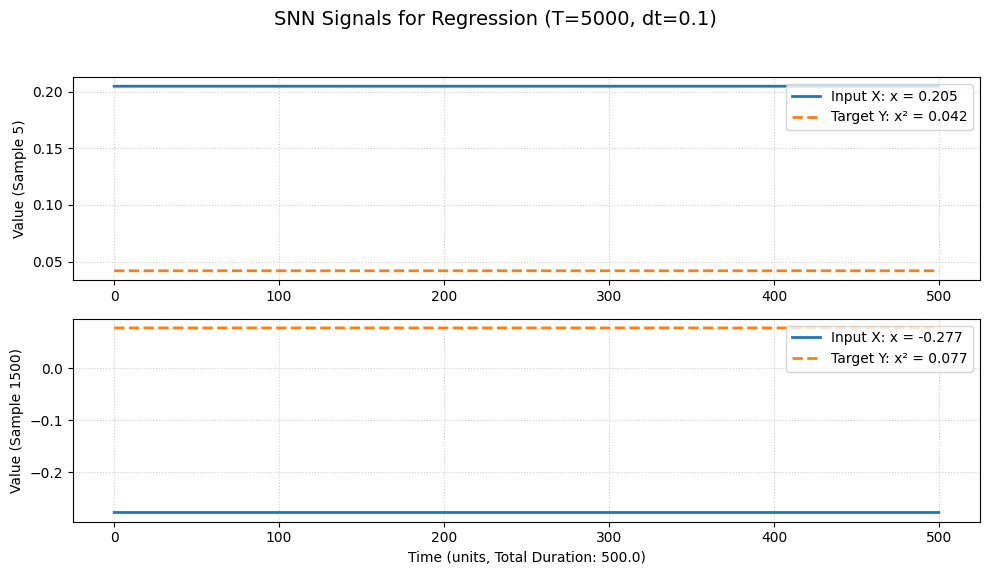

--------------------------------------------------
Verification: First batch from Train DataLoader:
Batch X shape: torch.Size([200, 5000, 1]) (Expected: (200, 5000, 1))
Batch Y shape: torch.Size([200, 5000, 1]) (Expected: (200, 5000, 1))


In [4]:
np.random.seed(8)
torch.manual_seed(8)

T = 5000       # Total simulation time steps (T)
dt = 0.1       # Time resolution (dt)
INPUT_FILENAME = 'regression_data.csv'
TIME_UNITS = np.arange(T) * dt

# --- DataLoader Configuration ---
batch_size = 200
TEST_SPLIT_RATIO = 0.2  # 20% of data for testing

# 1. Load and prepare the data signals
X_signal, Y_supervisor = load_and_prepare_signals(INPUT_FILENAME, T)

# 2. Split data and create DataLoaders
train_loader, test_loader, train_ds, test_ds = create_dataloaders(
    X_signal, 
    Y_supervisor, 
    batch_size=batch_size, 
    test_ratio=TEST_SPLIT_RATIO
)

# 3. Visualize a few instances (using the full signal set for simplicity in visualization)
visualize_signals(X_signal, Y_supervisor, TIME_UNITS, sample_indices=[5, 1500])

# Verify the shape of the first batch
X_batch, Y_batch = next(iter(train_loader))
print("-" * 50)
print("Verification: First batch from Train DataLoader:")
print(f"Batch X shape: {X_batch.shape} (Expected: ({batch_size}, {T}, 1))")
print(f"Batch Y shape: {Y_batch.shape} (Expected: ({batch_size}, {T}, 1))")

# ML-SNN

In [5]:
@torch.jit.script
def compute_output(s_e: torch.Tensor, s_i: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor) -> torch.Tensor:
    # Concatenate synaptic variables and compute a linear mapping
    cat = torch.cat([s_e, s_i], 1)
    return F.linear(cat, weight, bias)

@torch.jit.script
def compute_derivatives(
    V_e: torch.Tensor, n_e: torch.Tensor, s_e: torch.Tensor,
    V_i: torch.Tensor, n_i: torch.Tensor, s_i: torch.Tensor,
    I_e: torch.Tensor, I_i: torch.Tensor,
    omega_ee: torch.Tensor, omega_ei: torch.Tensor, 
    omega_ie: torch.Tensor, omega_ii: torch.Tensor,
    V1: float, V2: float, V3: float, V4: float,
    T_max: float, V_t: float, K_p: float,
    g_Ca: float, V_Ca: float, g_K: float, V_K: float, g_L: float, V_L: float,
    phi: float, ar_e: float, ad_e: float, ar_i: float, ad_i: float,
    gbar_e: float, gbar_i: float, E_ampa: float, E_gaba: float,
    Cm: float
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    m_inf_e = 0.5 * (1 + torch.tanh((V_e - V1) / V2))
    n_inf_e = 0.5 * (1 + torch.tanh((V_e - V3) / V4))
    # tau_n_e = 1.0 / torch.cosh((V_e - V3) / (2 * V4))
    tau_n_e = 1.0
    TM_e = T_max / (1 + torch.exp(-(V_e - V_t) / K_p))
    
    m_inf_i = 0.5 * (1 + torch.tanh((V_i - V1) / V2))
    n_inf_i = 0.5 * (1 + torch.tanh((V_i - V3) / V4))
    # tau_n_i = 1.0 / torch.cosh((V_i - V3) / (2 * V4))
    tau_n_i = 1.0
    TM_i = T_max / (1 + torch.exp(-(V_i - V_t) / K_p))
    
    I_syn_e = (gbar_e * torch.mm(s_e, omega_ee.transpose(0,1)) * (V_e - E_ampa) +
               gbar_i * torch.mm(s_i, omega_ei.transpose(0,1)) * (V_e - E_gaba))
    I_syn_i = (gbar_e * torch.mm(s_e, omega_ie.transpose(0,1)) * (V_i - E_ampa) +
               gbar_i * torch.mm(s_i, omega_ii.transpose(0,1)) * (V_i - E_gaba))
    
    dV_e = (I_e - g_L*(V_e - V_L) - g_K*n_e*(V_e - V_K) - g_Ca*m_inf_e*(V_e - V_Ca) - I_syn_e) / Cm
    dn_e = phi*(n_inf_e - n_e) / tau_n_e
    ds_e = ar_e * TM_e * (1.0 - s_e) - ad_e * s_e
    
    dV_i = (I_i - g_L*(V_i - V_L) - g_K*n_i*(V_i - V_K) - g_Ca*m_inf_i*(V_i - V_Ca) - I_syn_i) / Cm
    dn_i = phi*(n_inf_i - n_i) / tau_n_i
    ds_i = ar_i * TM_i * (1.0 - s_i) - ad_i * s_i
    
    return dV_e, dn_e, ds_e, dV_i, dn_i, ds_i

@torch.jit.script
def rk4_step(
    V_e: torch.Tensor, n_e: torch.Tensor, s_e: torch.Tensor,
    V_i: torch.Tensor, n_i: torch.Tensor, s_i: torch.Tensor,
    I_e: torch.Tensor, I_i: torch.Tensor, dt: float,
    omega_ee: torch.Tensor, omega_ei: torch.Tensor, 
    omega_ie: torch.Tensor, omega_ii: torch.Tensor,
    V1: float, V2: float, V3: float, V4: float,
    T_max: float, V_t: float, K_p: float,
    g_Ca: float, V_Ca: float, g_K: float, V_K: float, g_L: float, V_L: float,
    phi: float, ar_e: float, ad_e: float, ar_i: float, ad_i: float,
    gbar_e: float, gbar_i: float, E_ampa: float, E_gaba: float,
    Cm: float
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    k1 = compute_derivatives(V_e, n_e, s_e, V_i, n_i, s_i, I_e, I_i,
                             omega_ee, omega_ei, omega_ie, omega_ii,
                             V1, V2, V3, V4, T_max, V_t, K_p,
                             g_Ca, V_Ca, g_K, V_K, g_L, V_L,
                             phi, ar_e, ad_e, ar_i, ad_i,
                             gbar_e, gbar_i, E_ampa, E_gaba, Cm)
    V_e_k2 = V_e + 0.5 * dt * k1[0]
    n_e_k2 = n_e + 0.5 * dt * k1[1]
    s_e_k2 = s_e + 0.5 * dt * k1[2]
    V_i_k2 = V_i + 0.5 * dt * k1[3]
    n_i_k2 = n_i + 0.5 * dt * k1[4]
    s_i_k2 = s_i + 0.5 * dt * k1[5]
    k2 = compute_derivatives(V_e_k2, n_e_k2, s_e_k2, V_i_k2, n_i_k2, s_i_k2, I_e, I_i,
                             omega_ee, omega_ei, omega_ie, omega_ii,
                             V1, V2, V3, V4, T_max, V_t, K_p,
                             g_Ca, V_Ca, g_K, V_K, g_L, V_L,
                             phi, ar_e, ad_e, ar_i, ad_i,
                             gbar_e, gbar_i, E_ampa, E_gaba, Cm)
    V_e_k3 = V_e + 0.5 * dt * k2[0]
    n_e_k3 = n_e + 0.5 * dt * k2[1]
    s_e_k3 = s_e + 0.5 * dt * k2[2]
    V_i_k3 = V_i + 0.5 * dt * k2[3]
    n_i_k3 = n_i + 0.5 * dt * k2[4]
    s_i_k3 = s_i + 0.5 * dt * k2[5]
    k3 = compute_derivatives(V_e_k3, n_e_k3, s_e_k3, V_i_k3, n_i_k3, s_i_k3, I_e, I_i,
                             omega_ee, omega_ei, omega_ie, omega_ii,
                             V1, V2, V3, V4, T_max, V_t, K_p,
                             g_Ca, V_Ca, g_K, V_K, g_L, V_L,
                             phi, ar_e, ad_e, ar_i, ad_i,
                             gbar_e, gbar_i, E_ampa, E_gaba, Cm)
    V_e_k4 = V_e + dt * k3[0]
    n_e_k4 = n_e + dt * k3[1]
    s_e_k4 = s_e + dt * k3[2]
    V_i_k4 = V_i + dt * k3[3]
    n_i_k4 = n_i + dt * k3[4]
    s_i_k4 = s_i + dt * k3[5]
    k4 = compute_derivatives(V_e_k4, n_e_k4, s_e_k4, V_i_k4, n_i_k4, s_i_k4, I_e, I_i,
                             omega_ee, omega_ei, omega_ie, omega_ii,
                             V1, V2, V3, V4, T_max, V_t, K_p,
                             g_Ca, V_Ca, g_K, V_K, g_L, V_L,
                             phi, ar_e, ad_e, ar_i, ad_i,
                             gbar_e, gbar_i, E_ampa, E_gaba, Cm)
    V_e_new = V_e + (dt/6.0) * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
    n_e_new = n_e + (dt/6.0) * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
    s_e_new = s_e + (dt/6.0) * (k1[2] + 2*k2[2] + 2*k3[2] + k4[2])
    V_i_new = V_i + (dt/6.0) * (k1[3] + 2*k2[3] + 2*k3[3] + k4[3])
    n_i_new = n_i + (dt/6.0) * (k1[4] + 2*k2[4] + 2*k3[4] + k4[4])
    s_i_new = s_i + (dt/6.0) * (k1[5] + 2*k2[5] + 2*k3[5] + k4[5])
    return V_e_new, n_e_new, s_e_new, V_i_new, n_i_new, s_i_new


@torch.jit.script
def integrate_chunk_with_output(
    input: torch.Tensor,  
    chunk_size: int,
    init_V_e: torch.Tensor, init_n_e: torch.Tensor, init_s_e: torch.Tensor,
    init_V_i: torch.Tensor, init_n_i: torch.Tensor, init_s_i: torch.Tensor,
    dt: float, I: float,  
    omega_ee: torch.Tensor, omega_ei: torch.Tensor, 
    omega_ie: torch.Tensor, omega_ii: torch.Tensor,
    V1: float, V2: float, V3: float, V4: float,
    T_max: float, V_t: float, K_p: float,
    g_Ca: float, V_Ca: float, g_K: float, V_K: float, g_L: float, V_L: float,
    phi: float, ar_e: float, ad_e: float, ar_i: float, ad_i: float,
    gbar_e: float, gbar_i: float, E_ampa: float, E_gaba: float,
    Cm: float,
    proj_weight: torch.Tensor, proj_bias: torch.Tensor,
    out_weight: torch.Tensor, out_bias: torch.Tensor
) -> Tuple[torch.Tensor,
           Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor],
           Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]]:
    steps = chunk_size
    batch_size = input.size(0)
    
    # Initialize states:
    V_e, n_e, s_e = init_V_e, init_n_e, init_s_e
    V_i, n_i, s_i = init_V_i, init_n_i, init_s_i

    outputs = []  # Will collect output at every step.
    
    V_e_list = torch.jit.annotate(List[torch.Tensor], [])
    n_e_list = torch.jit.annotate(List[torch.Tensor], [])
    s_e_list = torch.jit.annotate(List[torch.Tensor], [])
    V_i_list = torch.jit.annotate(List[torch.Tensor], [])
    n_i_list = torch.jit.annotate(List[torch.Tensor], [])
    s_i_list = torch.jit.annotate(List[torch.Tensor], [])

    # projected_input = 80 * torch.tanh(F.linear(input, proj_weight, proj_bias) + I)
    projected_input = F.linear(input * 40.0, proj_weight, proj_bias) + I
    
    # Split into excitatory and inhibitory drive:
    NE = V_e.size(1)
    I_e = projected_input[:, :NE]
    I_i = projected_input[:, NE:]
    
    for t in range(steps):       

        # Perform one RK4 step with current input:
        V_e, n_e, s_e, V_i, n_i, s_i = rk4_step(
            V_e, n_e, s_e, V_i, n_i, s_i, I_e, I_i, dt,
            omega_ee, omega_ei, omega_ie, omega_ii,
            V1, V2, V3, V4, T_max, V_t, K_p,
            g_Ca, V_Ca, g_K, V_K, g_L, V_L,
            phi, ar_e, ad_e, ar_i, ad_i,
            gbar_e, gbar_i, E_ampa, E_gaba, Cm
        )
        # Compute output for this time step using the output layer:
        out = compute_output(s_e, s_i, out_weight, out_bias)
        outputs.append(out)
        
        V_e_list.append(V_e[0].clone())
        n_e_list.append(n_e[0].clone())
        s_e_list.append(s_e[0].clone())
        V_i_list.append(V_i[0].clone())
        n_i_list.append(n_i[0].clone())
        s_i_list.append(s_i[0].clone())
    

    outputs_tensor = torch.stack(outputs, dim=0)
    final_states = (V_e, n_e, s_e, V_i, n_i, s_i)
    all_states = (torch.stack(V_e_list, dim=0),
                  torch.stack(n_e_list, dim=0),
                  torch.stack(s_e_list, dim=0),
                  torch.stack(V_i_list, dim=0),
                  torch.stack(n_i_list, dim=0),
                  torch.stack(s_i_list, dim=0))

    return outputs_tensor, final_states, all_states


# --------------------------------------------------------------------
# Morris-Lecar SNN Model
# --------------------------------------------------------------------
class MorrisLecarSNN(nn.Module):
    def __init__(self, input_size, output_size, chunk_size, NE=250, NI=250, dt=0.1,
                 Cm=20.0, g_Ca=4.0, g_K=8.0, g_L=2.0, V_Ca=120.0, V_K=-84.0, V_L=-60.0,
                 phi=0.067, V1=-1.2, V2=18.0, V3=12.0, V4=17.4, ar_e=3.0, ad_e=0.1,
                 ar_i=3.0, ad_i=0.1, T_max=1.0, V_t=2.0, K_p=5.0, gbar_e=1.0, gbar_i=1.0,
                 E_ampa=0.0, E_gaba=-75.0, I= 70.0):
        super(MorrisLecarSNN, self).__init__()
        self.NE = NE
        self.NI = NI
        self.dt = dt
        self.hidden_size = NE + NI
        self.chunk_size = chunk_size

        # Model parameters
        self.I = I
        self.Cm = Cm
        self.g_Ca = g_Ca
        self.g_K = g_K
        self.g_L = g_L
        self.V_Ca = V_Ca
        self.V_K = V_K
        self.V_L = V_L
        self.phi = phi
        self.V1 = V1
        self.V2 = V2
        self.V3 = V3
        self.V4 = V4
        self.ar_e = ar_e
        self.ad_e = ad_e
        self.ar_i = ar_i
        self.ad_i = ad_i
        self.T_max = T_max
        self.V_t = V_t
        self.K_p = K_p
        self.gbar_e = gbar_e
        self.gbar_i = gbar_i
        self.E_ampa = E_ampa
        self.E_gaba = E_gaba

        # Input layer
        self.input_projection = nn.Linear(input_size, self.hidden_size)
        
        # Synaptic weights
        self.omega_ee_raw = nn.Parameter(torch.randn(NE, NE, device=device))
        self.omega_ei_raw = nn.Parameter(torch.randn(NE, NE, device=device))
        self.omega_ie_raw = nn.Parameter(torch.randn(NE, NE, device=device))
        self.omega_ii_raw = nn.Parameter(torch.randn(NE, NE, device=device))
        
        # Upper bound
        self.upper_bound = 1 / math.sqrt(self.hidden_size)

        # Output layer
        self.output_layer = nn.Linear(self.hidden_size, output_size)

        # State storage (if needed)
        self.store_states = False
        self._storage = None
        self._storage_idx = 0
    
    # Property to get bounded omega matrices
    @property
    def omega_ee(self):
        return torch.sigmoid(self.omega_ee_raw) * self.upper_bound
    
    @property
    def omega_ei(self):
        return torch.sigmoid(self.omega_ei_raw) * self.upper_bound
    
    @property
    def omega_ie(self):
        return torch.sigmoid(self.omega_ie_raw) * self.upper_bound
    
    @property
    def omega_ii(self):
        return torch.sigmoid(self.omega_ii_raw) * self.upper_bound
    
    def _init_storage(self, total_steps: int):
        device = self.input_projection.weight.device
        self._storage = {
            'V_e': torch.zeros(total_steps, self.NE, device=device),
            'n_e': torch.zeros(total_steps, self.NE, device=device),
            's_e': torch.zeros(total_steps, self.NE, device=device),
            'V_i': torch.zeros(total_steps, self.NI, device=device),
            'n_i': torch.zeros(total_steps, self.NI, device=device),
            's_i': torch.zeros(total_steps, self.NI, device=device)
        }
        self._storage_idx = 0

    def enable_storage(self, total_steps: int):
        self.store_states = True
        self._init_storage(total_steps)

    def disable_storage(self):
        self.store_states = False
        self._storage = None
        self._storage_idx = 0

    def get_storage(self):
        return self._storage

    def _init_states(self, batch_size: int):
        device = self.input_projection.weight.device
        V_e = 30 * torch.rand((batch_size, self.NE), device=device)
        n_e = torch.rand((batch_size, self.NE), device=device)
        s_e = torch.zeros((batch_size, self.NE), device=device)
        V_i = -50 + 30 * torch.rand((batch_size, self.NI), device=device)
        n_i = torch.rand((batch_size, self.NI), device=device)
        s_i = torch.zeros((batch_size, self.NI), device=device)
        return (V_e, n_e, s_e, V_i, n_i, s_i)

    def forward(self, input, states=None):
        """
        x_sequence: [batch_size, seq_len, input_size]
        For each time step, we require the output.
        We process the sequence in chunks using our scripted integration function.
        """
        batch_size, _ = input.shape
        outputs_list = []

        if states is None:
            states = self._init_states(batch_size)
        
        # We need to get the projection and output layer parameters.
        proj_weight = self.input_projection.weight
        proj_bias = self.input_projection.bias
        out_weight = self.output_layer.weight
        out_bias = self.output_layer.bias

        # Call the scripted integration function that returns outputs for each step in the chunk.
        chunk_outputs, states, all_states = integrate_chunk_with_output(
            input, self.chunk_size, states[0], states[1], states[2],
            states[3], states[4], states[5],
            self.dt, self.I,
            self.omega_ee, self.omega_ei, self.omega_ie, self.omega_ii,
            self.V1, self.V2, self.V3, self.V4,
            self.T_max, self.V_t, self.K_p,
            self.g_Ca, self.V_Ca, self.g_K, self.V_K, self.g_L, self.V_L,
            self.phi, self.ar_e, self.ad_e, self.ar_i, self.ad_i,
            self.gbar_e, self.gbar_i, self.E_ampa, self.E_gaba,
            self.Cm,
            proj_weight, proj_bias,
            out_weight, out_bias
        )
       
        chunk_outputs = chunk_outputs.transpose(0, 1)
        outputs_list.append(chunk_outputs)
        if self.store_states:
            steps = self.chunk_size
            with torch.no_grad():
                self._storage['V_e'][self._storage_idx:self._storage_idx + steps] = all_states[0]
                self._storage['n_e'][self._storage_idx:self._storage_idx + steps] = all_states[1]
                self._storage['s_e'][self._storage_idx:self._storage_idx + steps] = all_states[2]
                self._storage['V_i'][self._storage_idx:self._storage_idx + steps] = all_states[3]
                self._storage['n_i'][self._storage_idx:self._storage_idx + steps] = all_states[4]
                self._storage['s_i'][self._storage_idx:self._storage_idx + steps] = all_states[5]
                self._storage_idx += steps
        # Concatenate outputs along the time dimension.
        outputs = torch.cat(outputs_list, dim=1) 
        return outputs, states

    def warmup(self, input, warmup_duration, states=None):
        with torch.no_grad():
            batch_size, _ = input.shape
            outputs_list = []
    
            if states is None:
                states = self._init_states(batch_size)
            
            proj_weight = self.input_projection.weight
            proj_bias = self.input_projection.bias
            out_weight = self.output_layer.weight
            out_bias = self.output_layer.bias

            _, states, _ = integrate_chunk_with_output(
                input, warmup_duration, states[0], states[1], states[2],
                states[3], states[4], states[5],
                self.dt, self.I,
                self.omega_ee, self.omega_ei, self.omega_ie, self.omega_ii,
                self.V1, self.V2, self.V3, self.V4,
                self.T_max, self.V_t, self.K_p,
                self.g_Ca, self.V_Ca, self.g_K, self.V_K, self.g_L, self.V_L,
                self.phi, self.ar_e, self.ad_e, self.ar_i, self.ad_i,
                self.gbar_e, self.gbar_i, self.E_ampa, self.E_gaba,
                self.Cm,
                proj_weight, proj_bias,
                out_weight, out_bias
            )
           
        return states


    def plot_full_state(self, num_neurons=5, neuron_offset=2.0, figure_name=""):
        if not self.store_states or self._storage is None:
            print("Storage not enabled or no data stored!")
            return
        
        store = {k: v.cpu().numpy() for k, v in self._storage.items()}
        time_steps = store['V_e'].shape[0]
        time = np.arange(0, time_steps) * self.dt

        fig = plt.figure(figsize=(18, 12))
        plt.suptitle("Neuronal State Dynamics", fontsize=16)
        gs = fig.add_gridspec(3, 2)
        axs = {
            'V_e': fig.add_subplot(gs[0, 0]),
            'V_i': fig.add_subplot(gs[0, 1]),
            'n_e': fig.add_subplot(gs[1, 0]),
            'n_i': fig.add_subplot(gs[1, 1]),
            's_e': fig.add_subplot(gs[2, 0]),
            's_i': fig.add_subplot(gs[2, 1])
        }

        rand_e = np.random.choice(self.NE, num_neurons, replace=False)
        rand_i = np.random.choice(self.NI, num_neurons, replace=False)

        for idx, n in enumerate(rand_e):
            offset = idx * neuron_offset
            axs['V_e'].plot(time, (store['V_e'][:, n]) / 150 + offset, label=f'Neuron {n}')
            axs['n_e'].plot(time, store['n_e'][:, n] + offset)
            axs['s_e'].plot(time, store['s_e'][:, n] + offset)

        for idx, n in enumerate(rand_i):
            offset = idx * neuron_offset
            axs['V_i'].plot(time, (store['V_i'][:, n]) / 150 + offset, label=f'Neuron {n}')
            axs['n_i'].plot(time, store['n_i'][:, n] + offset)
            axs['s_i'].plot(time, store['s_i'][:, n] + offset)

        titles = {
            'V_e': "Excitatory Membrane Potentials",
            'V_i': "Inhibitory Membrane Potentials",
            'n_e': "Excitatory Gating Variables",
            'n_i': "Inhibitory Gating Variables",
            's_e': "Excitatory Synaptic Variables",
            's_i': "Inhibitory Synaptic Variables"
        }
        for key, ax in axs.items():
            ax.set_title(titles[key])
            ax.set_xlabel("Time (ms)")
            ax.grid(True, alpha=0.3)
            if key in ['V_e', 'V_i']:
                ax.legend()

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        if figure_name:
            plt.savefig(figure_name, bbox_inches='tight')
        plt.show()

## Define the ML-SNN architecture and training parameters

In [6]:
np.random.seed(8)
torch.manual_seed(8)

chunk_size = 100
epochs = 20
states = None

NE = 250
NI = 250

model = MorrisLecarSNN(input_size=1, output_size=1, chunk_size=chunk_size, NE=NE, NI=NI, dt=0.1).to(device)

optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=1e-4)

criterion = nn.MSELoss()

signal_len = int(X_signal[0].size(0))

initial_model_ckeckpoint = 'regression-initial.pth'
trained_model_checkpoint = 'regression-final.pth'

In [7]:
torch.save(model.state_dict(), initial_model_ckeckpoint)
print(f"Initial model state saved to {initial_model_ckeckpoint}")

Initial model state saved to regression-initial.pth


## Training loop

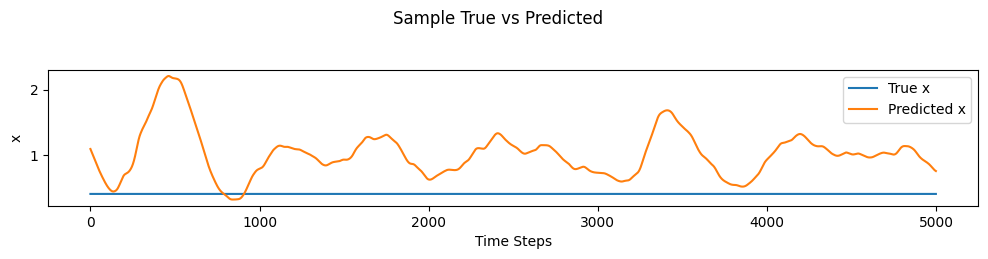

Sample Expected Value:  [0.40975264] Model Output:  [0.9937867]
Epoch [1/20], Avg Time-Distributed MSE Loss: 66.83325130194426, Avg Scalar Prediction MAE: 0.9368972492218017


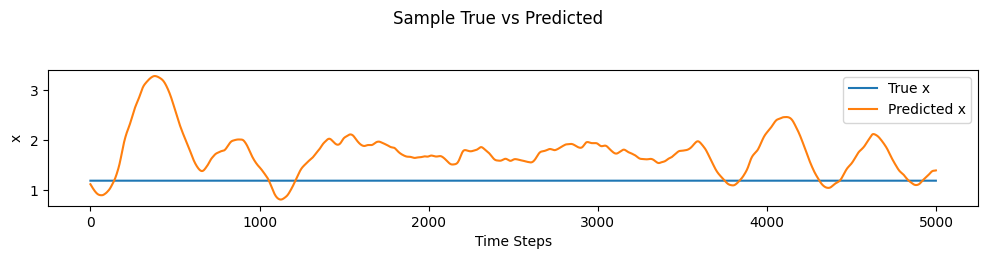

Sample Expected Value:  [1.19168] Model Output:  [1.6822984]
Epoch [2/20], Avg Time-Distributed MSE Loss: 28.091882137954236, Avg Scalar Prediction MAE: 0.46630441093444824


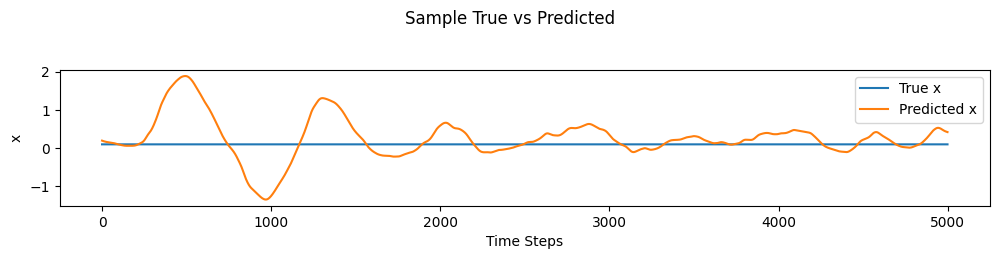

Sample Expected Value:  [0.09685699] Model Output:  [0.23609887]
Epoch [3/20], Avg Time-Distributed MSE Loss: 18.566181713342665, Avg Scalar Prediction MAE: 0.3312328634262085


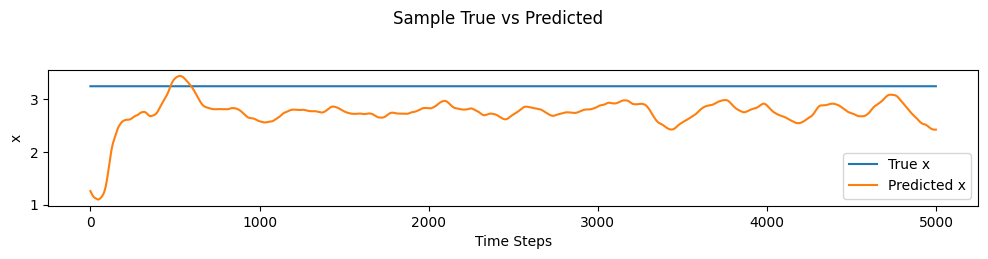

Sample Expected Value:  [3.2485332] Model Output:  [2.7806215]
Epoch [4/20], Avg Time-Distributed MSE Loss: 15.443241951614619, Avg Scalar Prediction MAE: 0.2956990385055542


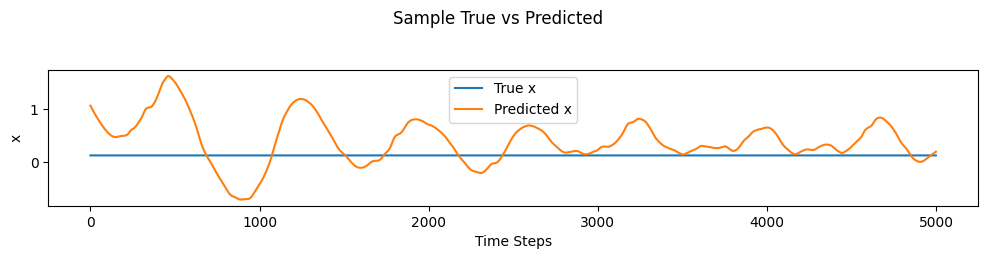

Sample Expected Value:  [0.12234554] Model Output:  [0.37666944]
Epoch [5/20], Avg Time-Distributed MSE Loss: 13.952024321258069, Avg Scalar Prediction MAE: 0.26366084957122804


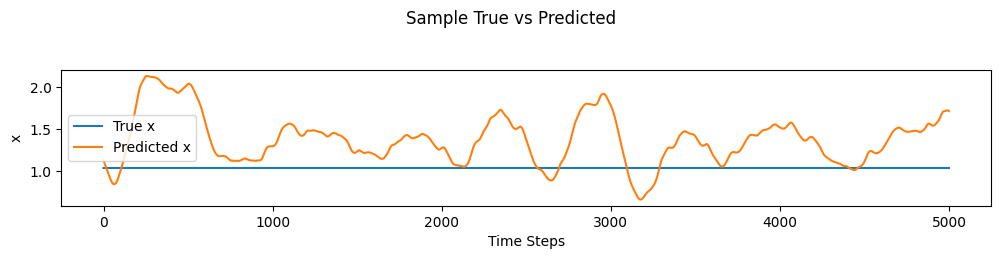

Sample Expected Value:  [1.0411857] Model Output:  [1.3214371]
Epoch [6/20], Avg Time-Distributed MSE Loss: 12.736282052099705, Avg Scalar Prediction MAE: 0.2404572105407715


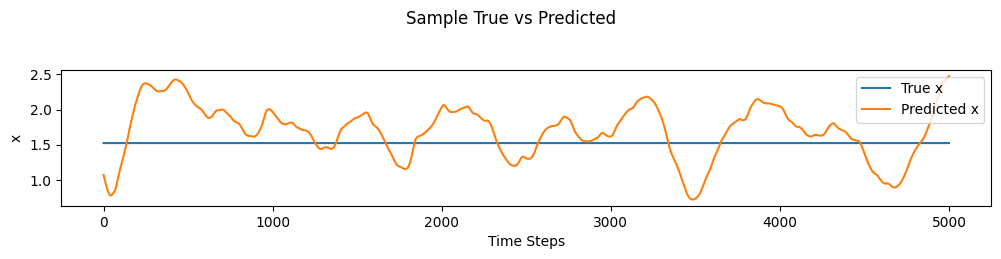

Sample Expected Value:  [1.5236729] Model Output:  [1.6233149]
Epoch [7/20], Avg Time-Distributed MSE Loss: 11.775804279744625, Avg Scalar Prediction MAE: 0.22481626319885253


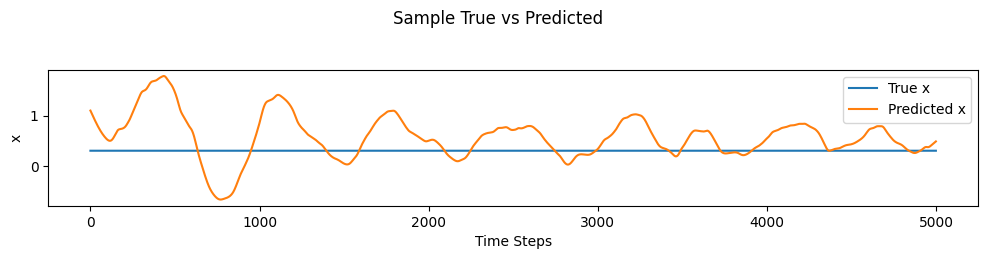

Sample Expected Value:  [0.30222854] Model Output:  [0.5194951]
Epoch [8/20], Avg Time-Distributed MSE Loss: 10.74338699541986, Avg Scalar Prediction MAE: 0.20857607460021974


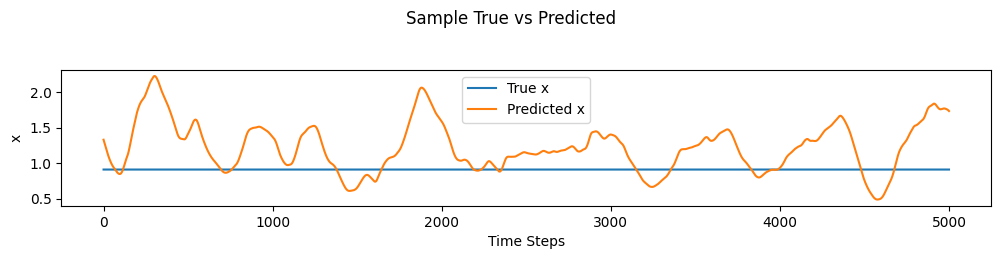

Sample Expected Value:  [0.9101161] Model Output:  [1.1818643]
Epoch [9/20], Avg Time-Distributed MSE Loss: 9.822201713174582, Avg Scalar Prediction MAE: 0.1848300733566284


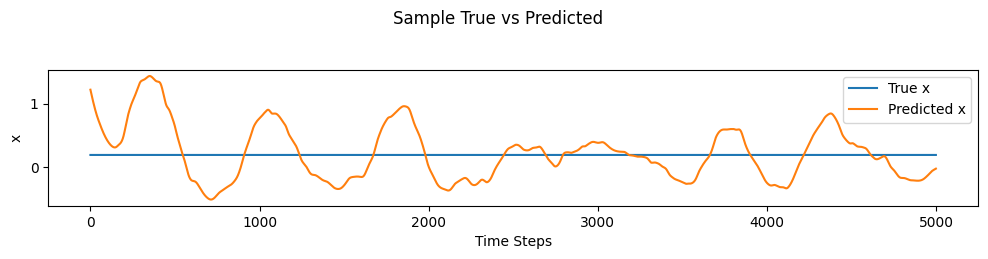

Sample Expected Value:  [0.19624352] Model Output:  [0.1724206]
Epoch [10/20], Avg Time-Distributed MSE Loss: 9.030574357509613, Avg Scalar Prediction MAE: 0.16961713743209839


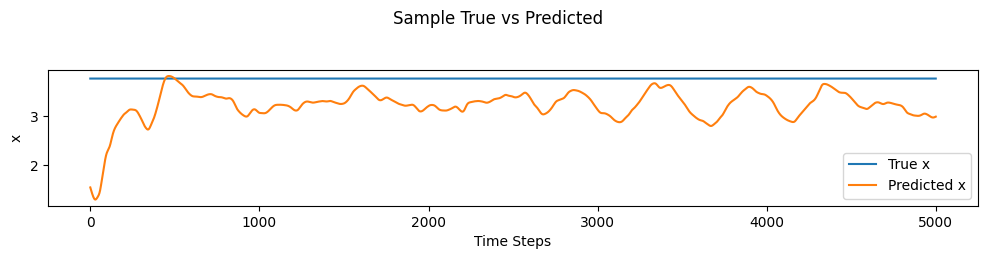

Sample Expected Value:  [3.7743518] Model Output:  [3.2572963]
Epoch [11/20], Avg Time-Distributed MSE Loss: 8.485422056168318, Avg Scalar Prediction MAE: 0.1546736397743225


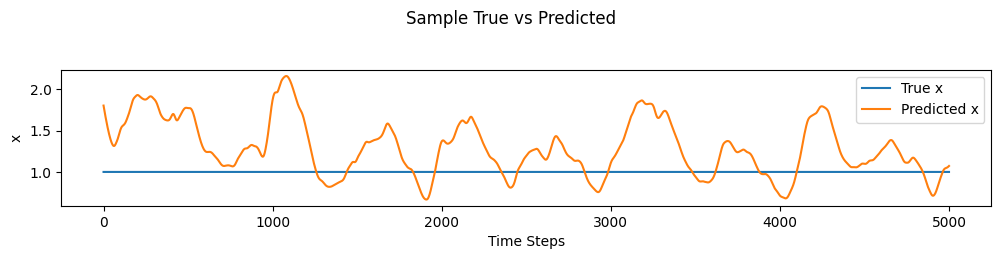

Sample Expected Value:  [1.0023365] Model Output:  [1.2152691]
Epoch [12/20], Avg Time-Distributed MSE Loss: 7.884296517074108, Avg Scalar Prediction MAE: 0.14322462892532348


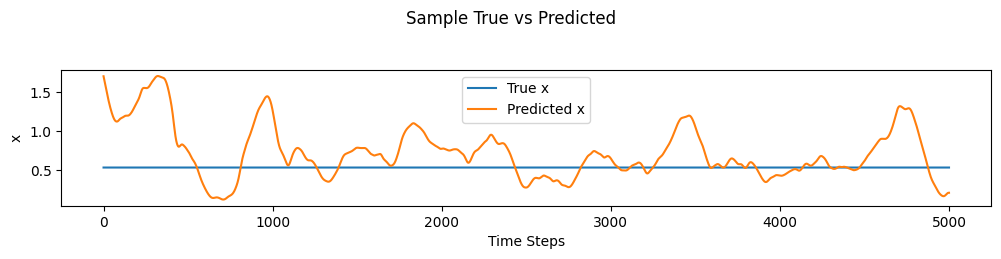

Sample Expected Value:  [0.5352245] Model Output:  [0.6276542]
Epoch [13/20], Avg Time-Distributed MSE Loss: 7.520515814237297, Avg Scalar Prediction MAE: 0.13519356536865235


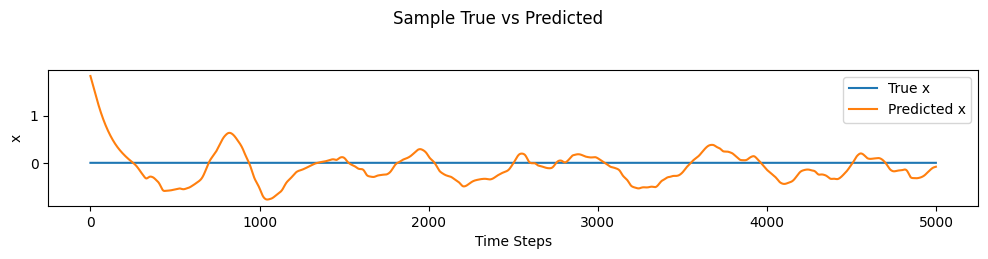

Sample Expected Value:  [0.00040948] Model Output:  [-0.09258253]
Epoch [14/20], Avg Time-Distributed MSE Loss: 7.040520365908742, Avg Scalar Prediction MAE: 0.12646210479736328


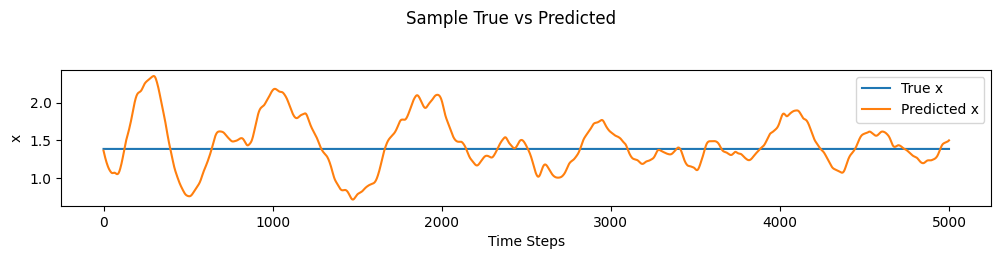

Sample Expected Value:  [1.3872417] Model Output:  [1.3929353]
Epoch [15/20], Avg Time-Distributed MSE Loss: 6.840305952727794, Avg Scalar Prediction MAE: 0.12214137172698974


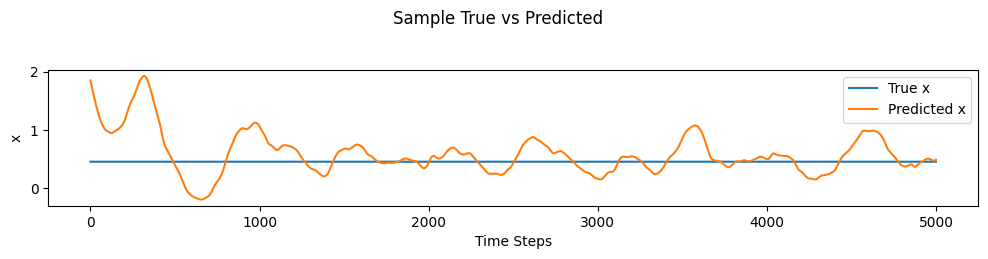

Sample Expected Value:  [0.45372227] Model Output:  [0.52920145]
Epoch [16/20], Avg Time-Distributed MSE Loss: 6.54471305757761, Avg Scalar Prediction MAE: 0.11611209154129028


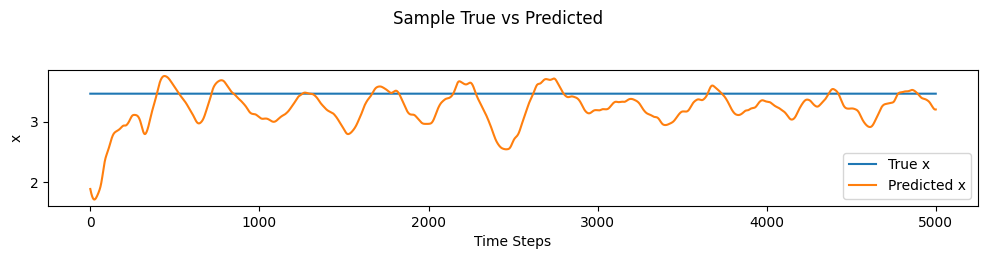

Sample Expected Value:  [3.4661086] Model Output:  [3.2844012]
Epoch [17/20], Avg Time-Distributed MSE Loss: 6.267333241738379, Avg Scalar Prediction MAE: 0.10767640733718872


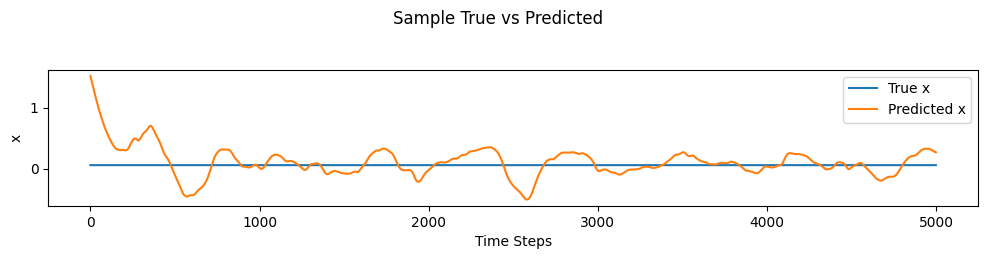

Sample Expected Value:  [0.05823182] Model Output:  [0.05739804]
Epoch [18/20], Avg Time-Distributed MSE Loss: 6.076216392032802, Avg Scalar Prediction MAE: 0.10565651988983155


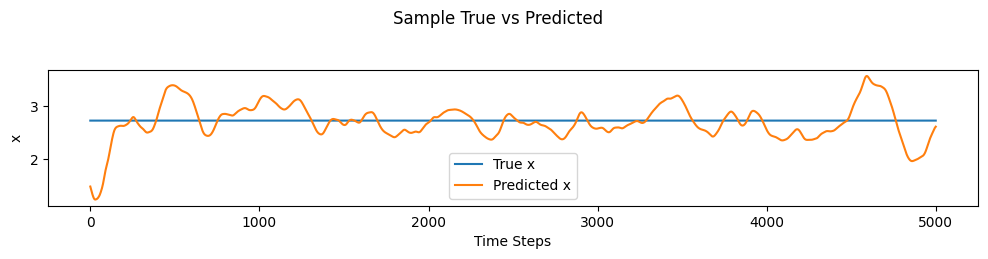

Sample Expected Value:  [2.729889] Model Output:  [2.6851053]
Epoch [19/20], Avg Time-Distributed MSE Loss: 5.962418348714709, Avg Scalar Prediction MAE: 0.09990430068969726


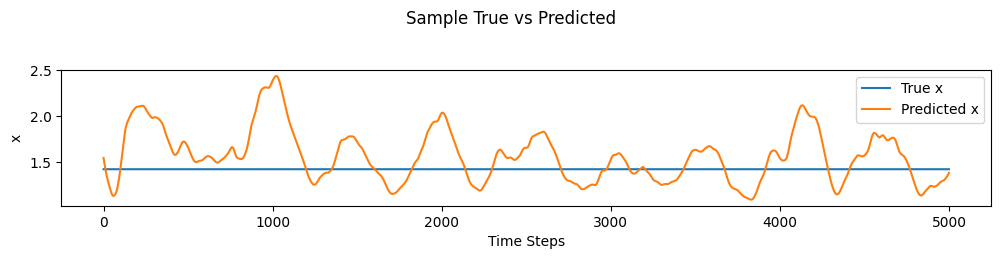

Sample Expected Value:  [1.4216663] Model Output:  [1.4833888]
Epoch [20/20], Avg Time-Distributed MSE Loss: 5.804391482658684, Avg Scalar Prediction MAE: 0.09754786396026612
Model and optimizer state saved successfully!
CPU times: user 1h 6min 30s, sys: 19.7 s, total: 1h 6min 49s
Wall time: 1h 6min 44s


In [8]:
%%time

np.random.seed(8)
torch.manual_seed(8)
warmup_duration = 200 #20ms

# Training loop
for epoch in range(epochs):
    model.train()
    loss = 0.0
    total_loss = 0.0
    abs_error = 0.0
    total_samples = 0

    for X_batch, Y_batch in train_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        input_seq = X_batch[:,0]

        optimizer.zero_grad()
        states = None  # Reset recurrent states at the beginning of the batch
        outputs_list = []  # To accumulate outputs over time for predictions
        
        with torch.no_grad():
            states = model.warmup(torch.zeros(batch_size, 1).to(device), warmup_duration, states)        

        # Process the sequence in TBPTT chunks
        for start in range(0, signal_len, chunk_size):
            y_chunk = Y_batch[:,start: start+chunk_size,:].to(device)
            
            chunk_outputs, states = model(input_seq, states)
            loss = criterion(chunk_outputs, y_chunk)

            loss.backward()
            total_loss += loss.detach().item() * X_batch.size(0)

            outputs_list.append(chunk_outputs.detach())

            # Detach states to prevent the computation graph from growing too large
            if states is not None:
                states = tuple(s.detach() for s in states)

        optimizer.step()
        
        total_samples += X_batch.size(0)
        outputs_list = torch.concatenate(outputs_list, axis = 1)    
        outputs_number = torch.mean(outputs_list[:, -2500:], dim=1)
        abs_error += torch.sum(torch.abs(outputs_number - Y_batch[:, 0, :] )).item()

    plot_output(Y_batch.detach().cpu().numpy(), outputs_list[0].cpu().numpy())
    avg_loss = total_loss / total_samples
    avg_mae = abs_error / total_samples
    
    print("Sample Expected Value: ",Y_batch[0,0].cpu().numpy(), "Model Output: ", outputs_number[0].cpu().numpy())
    print(f"Epoch [{epoch+1}/{epochs}], Avg Time-Distributed MSE Loss: {avg_loss}, Avg Scalar Prediction MAE: {avg_mae}")

checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}

torch.save(checkpoint, trained_model_checkpoint)
print("Model and optimizer state saved successfully!")

## Testing the model

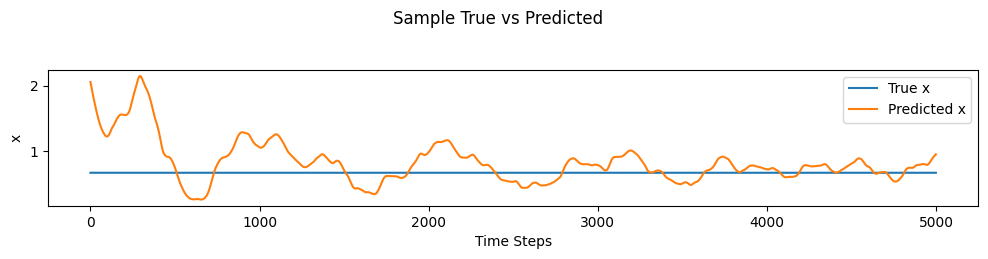

Avg Time-Distributed MSE Loss: 5.731214
Avg Scalar Prediction MAE: 0.092447 (Mean Absolute Error)
R-squared (R²) Score on the Test Set: 0.9856


In [9]:
np.random.seed(1)
torch.manual_seed(1)

model.eval()
test_loss = 0.0
test_abs_error = 0.0
total_samples = 0

all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)
        signal_len = Y_batch.size(1)
        states = None  # Reset recurrent states at the beginning of the batch
        outputs_list = []  # To accumulate outputs over time for predictions
        
        with torch.no_grad():
            states = model.warmup(torch.zeros(Y_batch.size(0), 1).to(device), warmup_duration, states)        
        model.enable_storage(Y_batch[0].size(0))

        for start in range(0, signal_len, chunk_size):
            y_chunk = Y_batch[:,start: start+chunk_size,:].to(device)
            input_seq = X_batch[:,start]
            
            chunk_outputs, states = model(input_seq, states)
            loss = criterion(chunk_outputs, y_chunk)
            test_loss += loss.item() * X_batch.size(0)
            
            outputs_list.append(chunk_outputs.detach())

            if states is not None:
                states = tuple(s.detach() for s in states)
        
        outputs_list = torch.concatenate(outputs_list, axis = 1)    
        outputs_number = torch.mean(outputs_list[:, -2500:], dim=1)
        
        all_preds.append(outputs_number.cpu().numpy())
        all_targets.append(Y_batch[:, 0, :].cpu().numpy())
        
        test_abs_error += torch.sum(torch.abs(outputs_number - Y_batch[:, 0, :] )).item()
        total_samples += X_batch.size(0)

plot_output(Y_batch.detach().cpu().numpy(), outputs_list[0].cpu().numpy())

avg_test_loss = test_loss / total_samples
avg_test_mae = test_abs_error / total_samples

all_targets = np.concatenate(all_targets).flatten()
all_preds = np.concatenate(all_preds).flatten()

# Calculate the R-squared score
r2 = r2_score(all_targets, all_preds)

print(f"Avg Time-Distributed MSE Loss: {avg_test_loss:.6f}")
print(f"Avg Scalar Prediction MAE: {avg_test_mae:.6f} (Mean Absolute Error)")
print(f"R-squared (R²) Score on the Test Set: {r2:.4f}")

## Plotting paper's figures

In [10]:
%config InlineBackend.figure_format = 'retina'

config = {
    'figure.figsize': (8, 6),
    'figure.autolayout': True,
    'font.size': 15,
    'lines.linewidth': 3,
    'axes.titlesize': 24,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,     
    'ytick.labelsize': 16,        
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'legend.fontsize': 18,
    'axes.spines.top': False,
    'axes.spines.right': False
}

plt.rcParams.update(config)

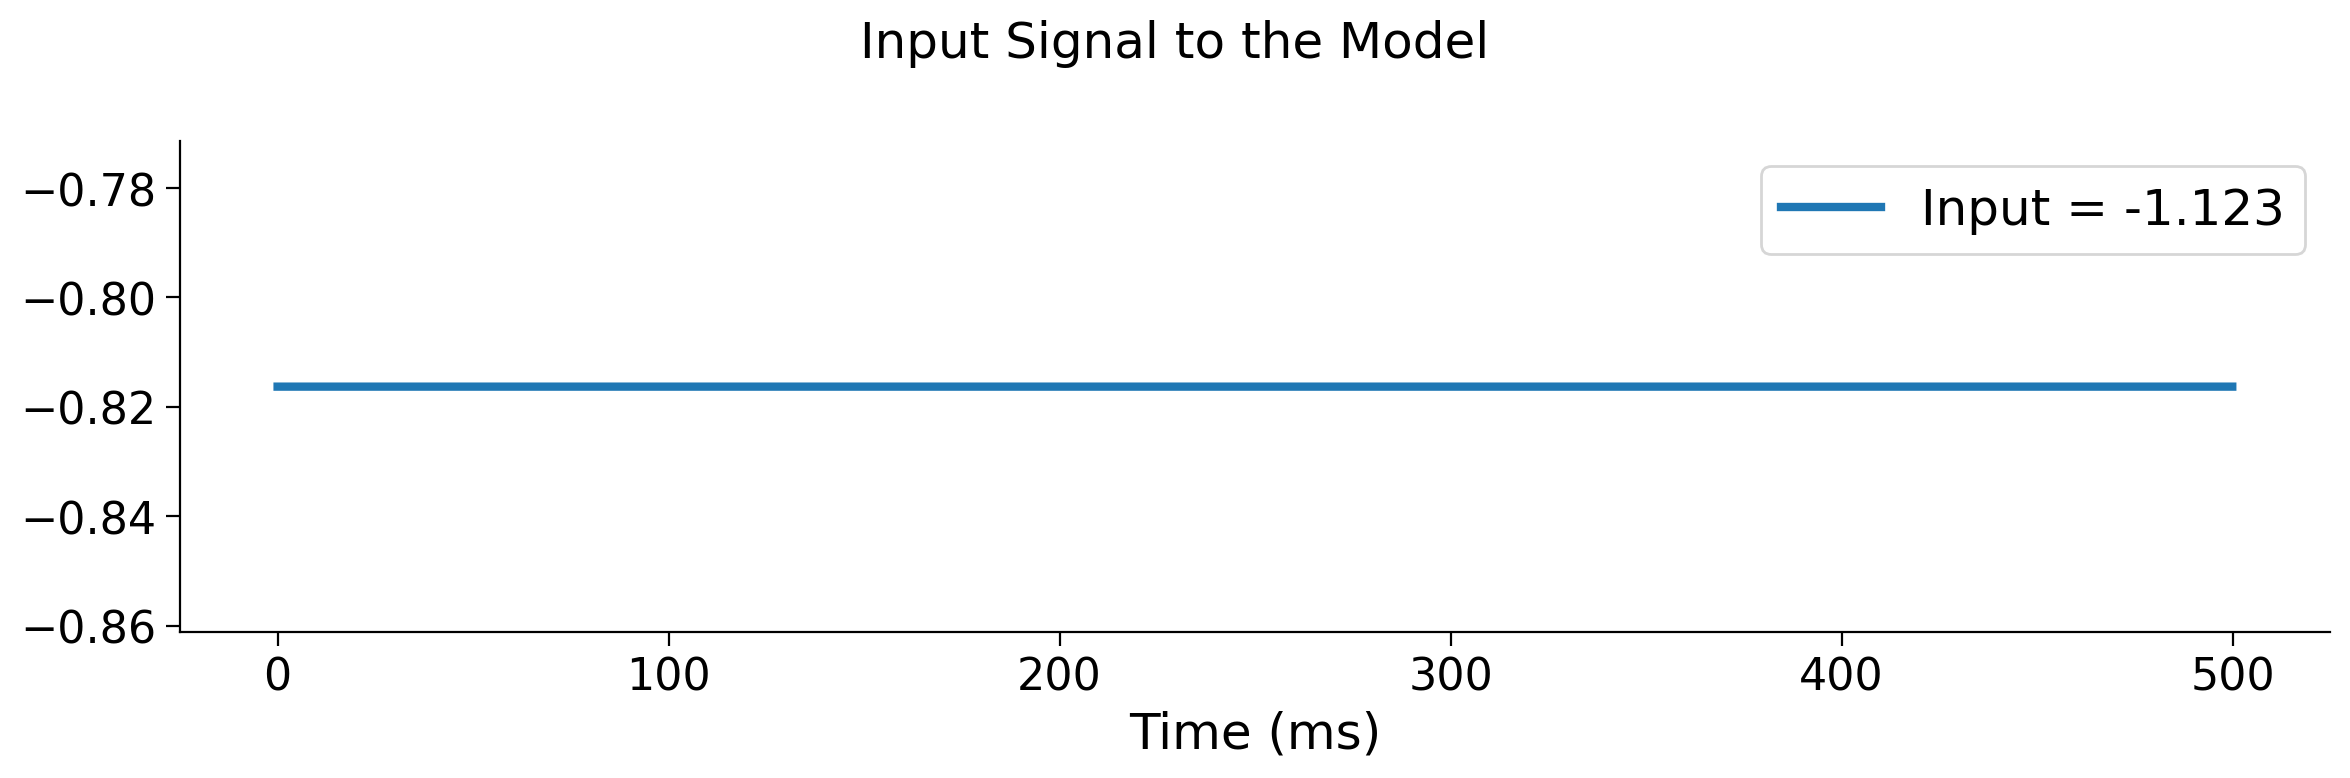

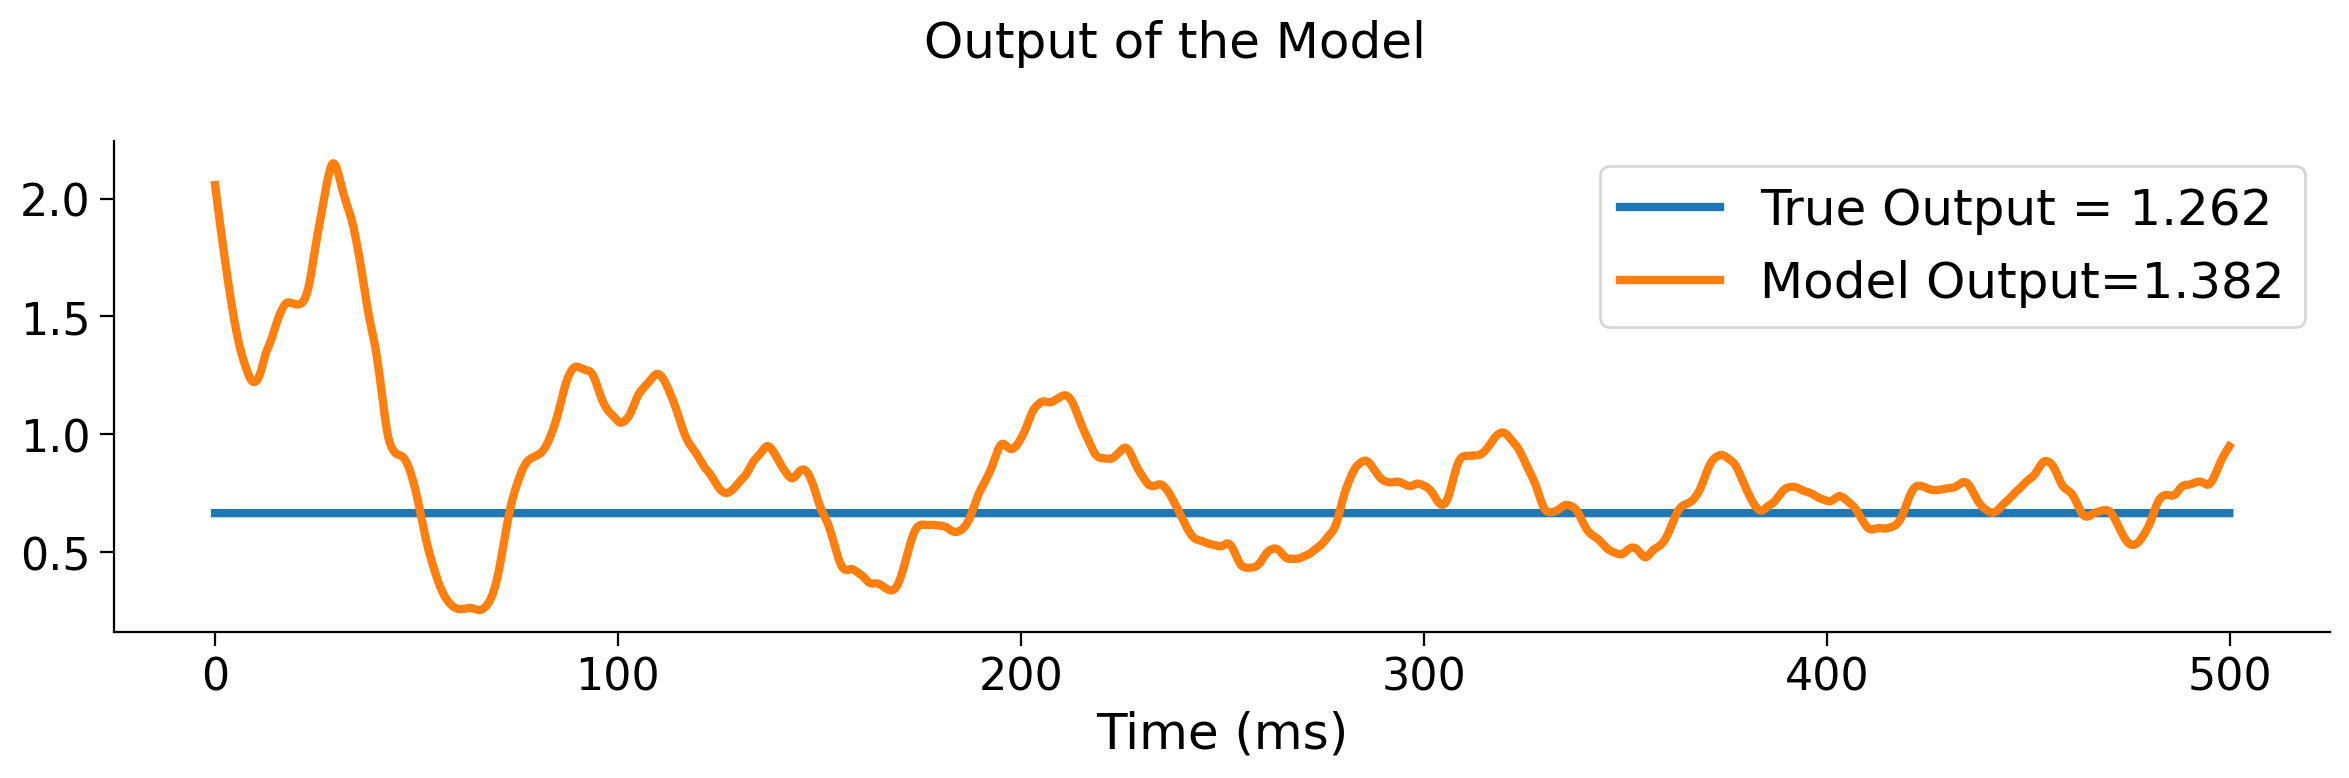

In [11]:
dt = 0.1
generation_len = Y_batch[0].size(0)
plt.figure(figsize=(12, 4))
plt.plot(np.arange(0, generation_len) * dt, X_batch[0].cpu().numpy(), label=f"Input = {X_batch[1,0].cpu().numpy().item():.4}")
plt.xlabel('Time (ms)')
plt.legend()
plt.suptitle('Input Signal to the Model')
plt.savefig('Regression-model-input.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(np.arange(0, generation_len) * dt, Y_batch[0].cpu().numpy(), label=f"True Output = {Y_batch[1,0].cpu().numpy().item():.4}")
plt.plot(np.arange(0, generation_len) * dt, outputs_list[0].cpu().numpy(), label=f"Model Output={torch.mean(outputs_list[:, -2500:], dim=1)[1].item():.4}")

plt.legend()
plt.xlabel('Time (ms)')
plt.suptitle('Output of the Model')
plt.savefig('Regression-model-output.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
def savePlot_full_state(data, num_neurons=5, neuron_offset=1.0, figure_name_prefix="", linewidth=1.5):
    store = {k: v.cpu().numpy() for k, v in data.items()}
    time_steps = store['V_e'].shape[0]  
    time = np.arange(0, time_steps) * dt
    
    plot_configs = {
        'V_e': ("Excitatory Membrane Potentials", "C", store['V_e'], 0, lambda x: (x)/150),
        'V_i': ("Inhibitory Membrane Potentials", "B", store['V_i'], 0, lambda x: (x)/150),
        'n_e': ("Excitatory Gating Variables", "G", store['n_e'], 0, lambda x: x),
        'n_i': ("Inhibitory Gating Variables", "F", store['n_i'], 0, lambda x: x),
        's_e': ("Excitatory Synaptic Variables", "E", store['s_e'], 0, lambda x: x),
        's_i': ("Inhibitory Synaptic Variables", "D", store['s_i'], 0, lambda x: x)
    }
    
    rand_e = np.random.choice(250, num_neurons, False)
    rand_i = np.random.choice(250, num_neurons, False)
    
    # Create and save individual plots
    for plot_key, (title, order, data, dim, transform) in plot_configs.items():
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111)
        
        if 'e' in plot_key:
            neurons = rand_e
            neuron_type = 'Excitatory'
        else:
            neurons = rand_i
            neuron_type = 'Inhibitory'
            
        for idx, n in enumerate(neurons):
            offset = idx * neuron_offset
            ax.plot(time, transform(data[:, n]) + offset + 1,
                   linewidth=linewidth, label=f'{neurons[idx]}')
            x = np.arange(0, 500)
            y = np.full_like(x, offset + 1)
            ax.plot(x, y, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    
        plt.gca().spines['bottom'].set_visible(False)
        plt.gca().spines['left'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.gca().spines['top'].set_visible(False)
        
        ax.set_title(title, fontsize=24, y=1.1)
        plt.title(order, fontsize=30, loc='left', y=1.2, x=-0.1)
        if title == "Excitatory Gating Variables" or title == "Inhibitory Gating Variables":
            ax.set_xlabel("Time (ms)", fontsize=16)
            y_min_final, y_max_final = ax.get_ylim() 
            y_range_final = y_max_final - y_min_final
            y_pos = y_min_final - 0.02 * y_range_final
            x_start_bar = 0
            x_end_bar = 20
            ax.plot([x_start_bar, x_end_bar], [y_pos, y_pos], color='black', linewidth=5, clip_on=False)
            ax.text((x_start_bar + x_end_bar) / 2, y_pos - 0.03 * y_range_final, "20 ms",
             ha='center', va='top', fontsize=16, clip_on=False)

        ax.grid(True, alpha=0.3)
        ax.set_yticks([1, 2, 3, 4, 5])
        ax.set_ylabel("Neurons", fontsize=16)
        ax.set_xticks([])
    
        # Save the figure
        if figure_name_prefix:
            filename = f"{figure_name_prefix}_{plot_key}.svg"
            plt.savefig(filename, format='svg', dpi=300, bbox_inches='tight')
            plt.show()
        plt.close(fig)

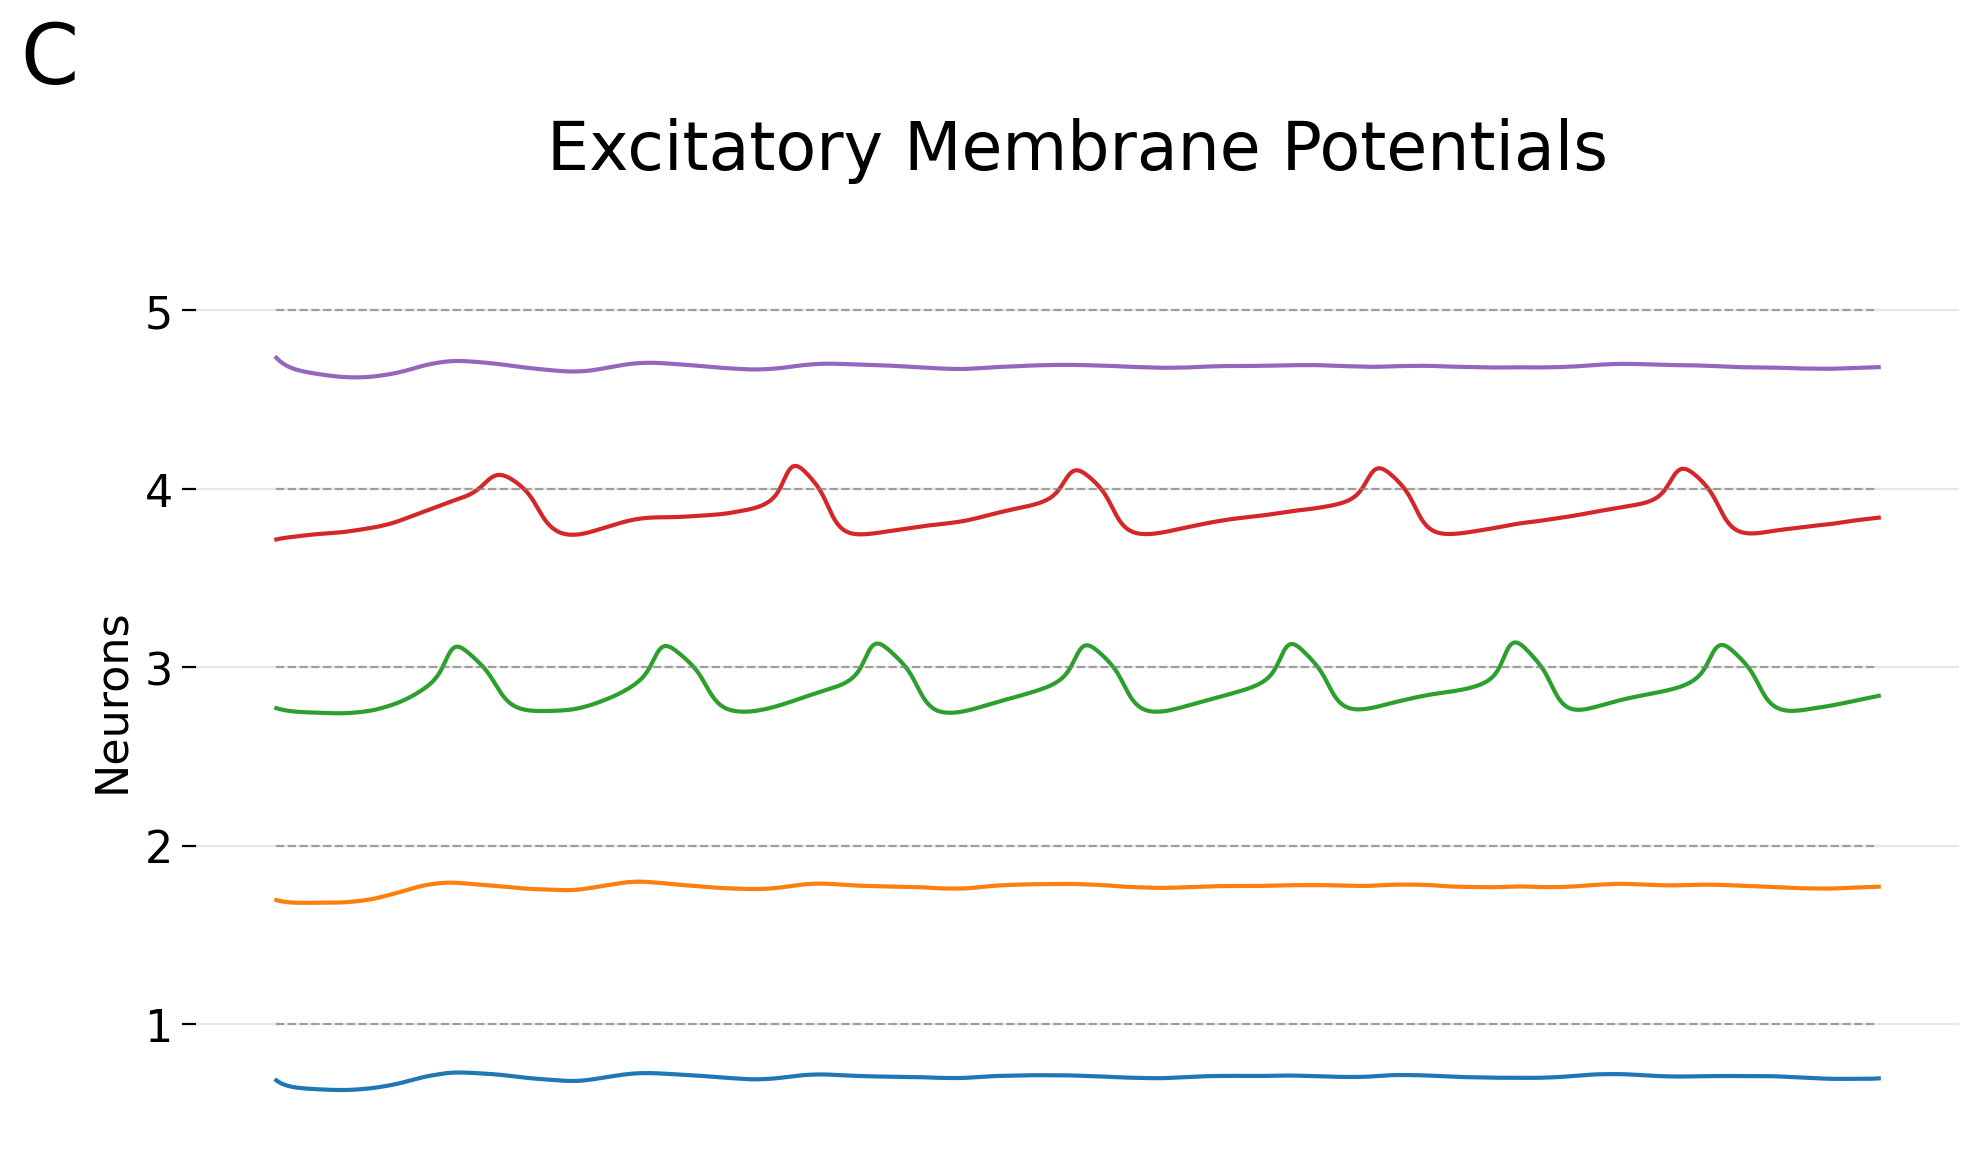

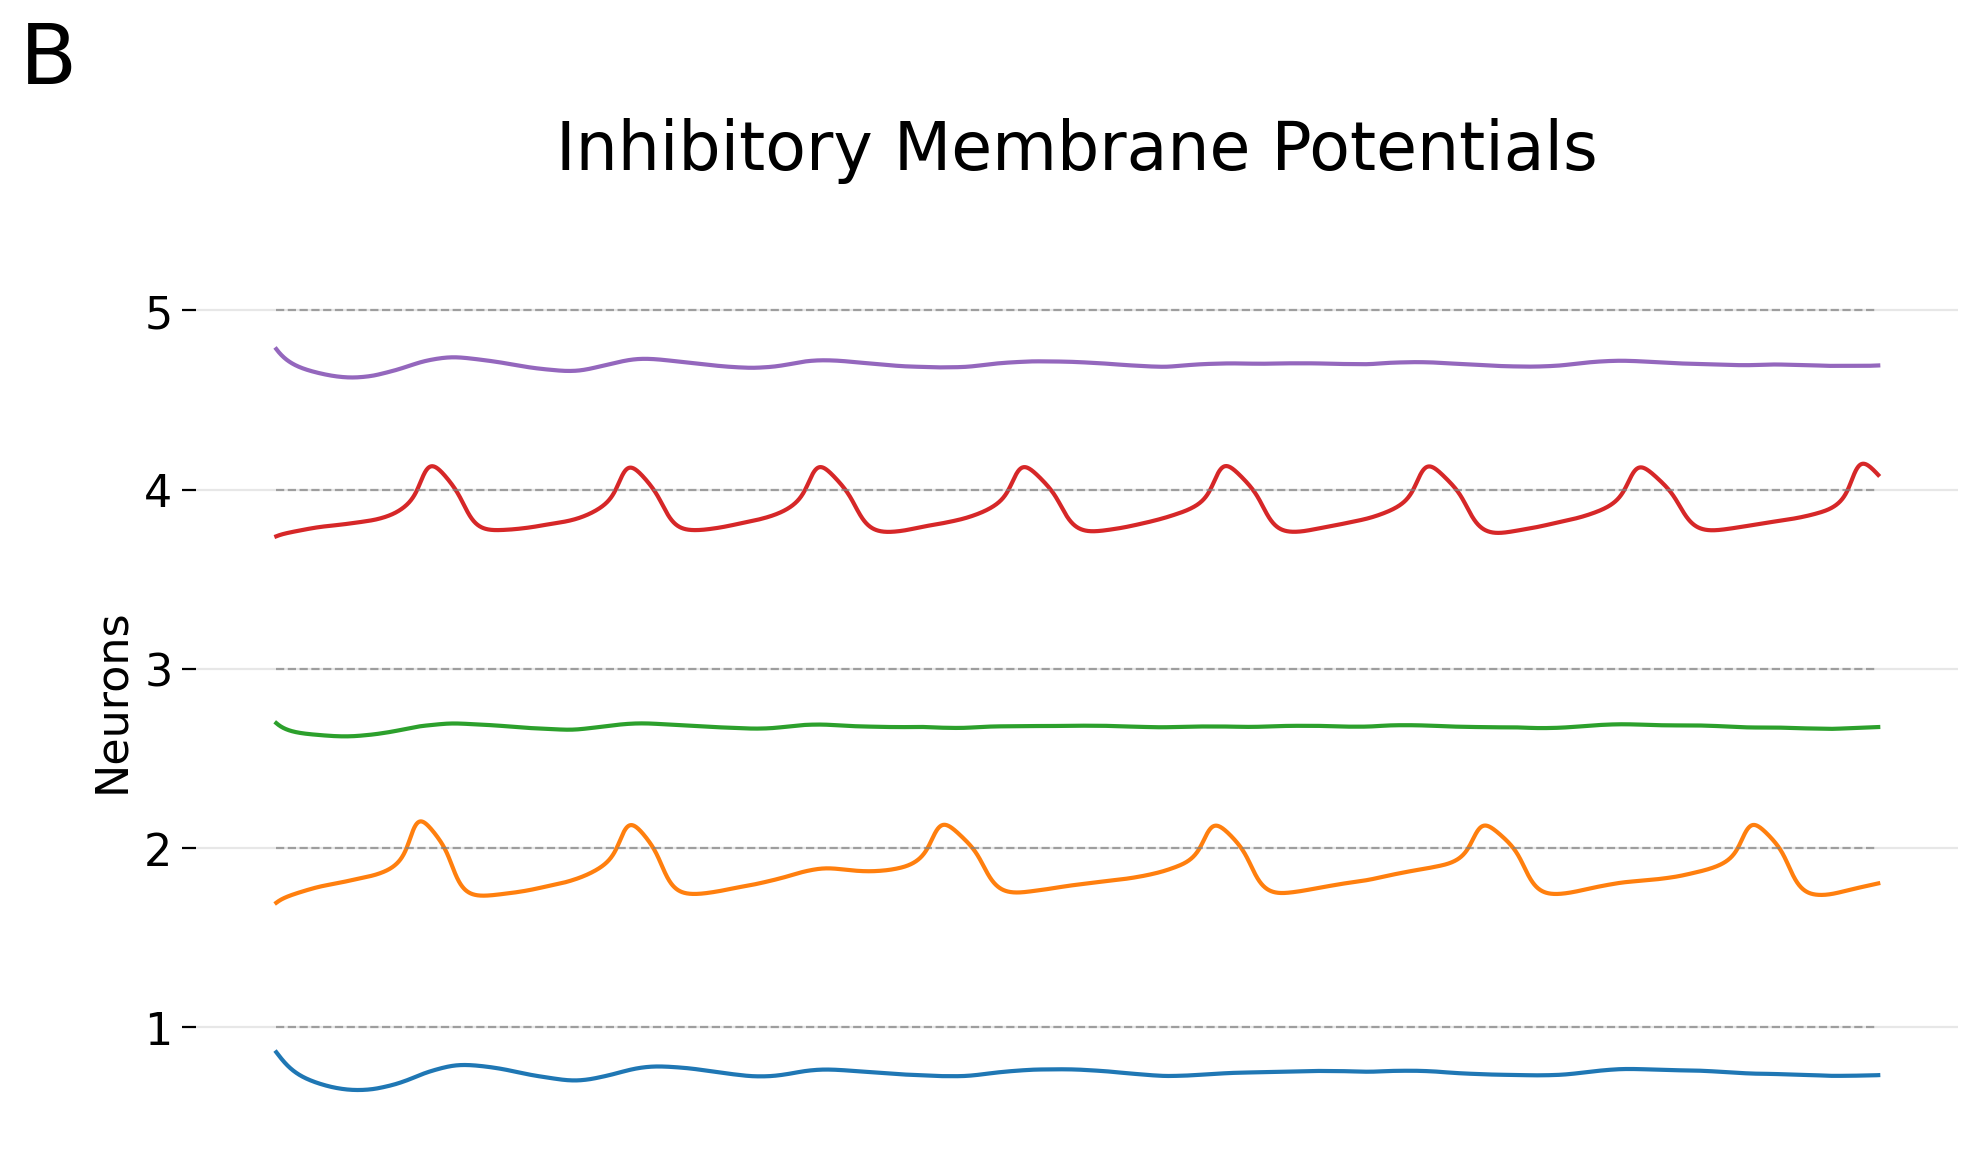

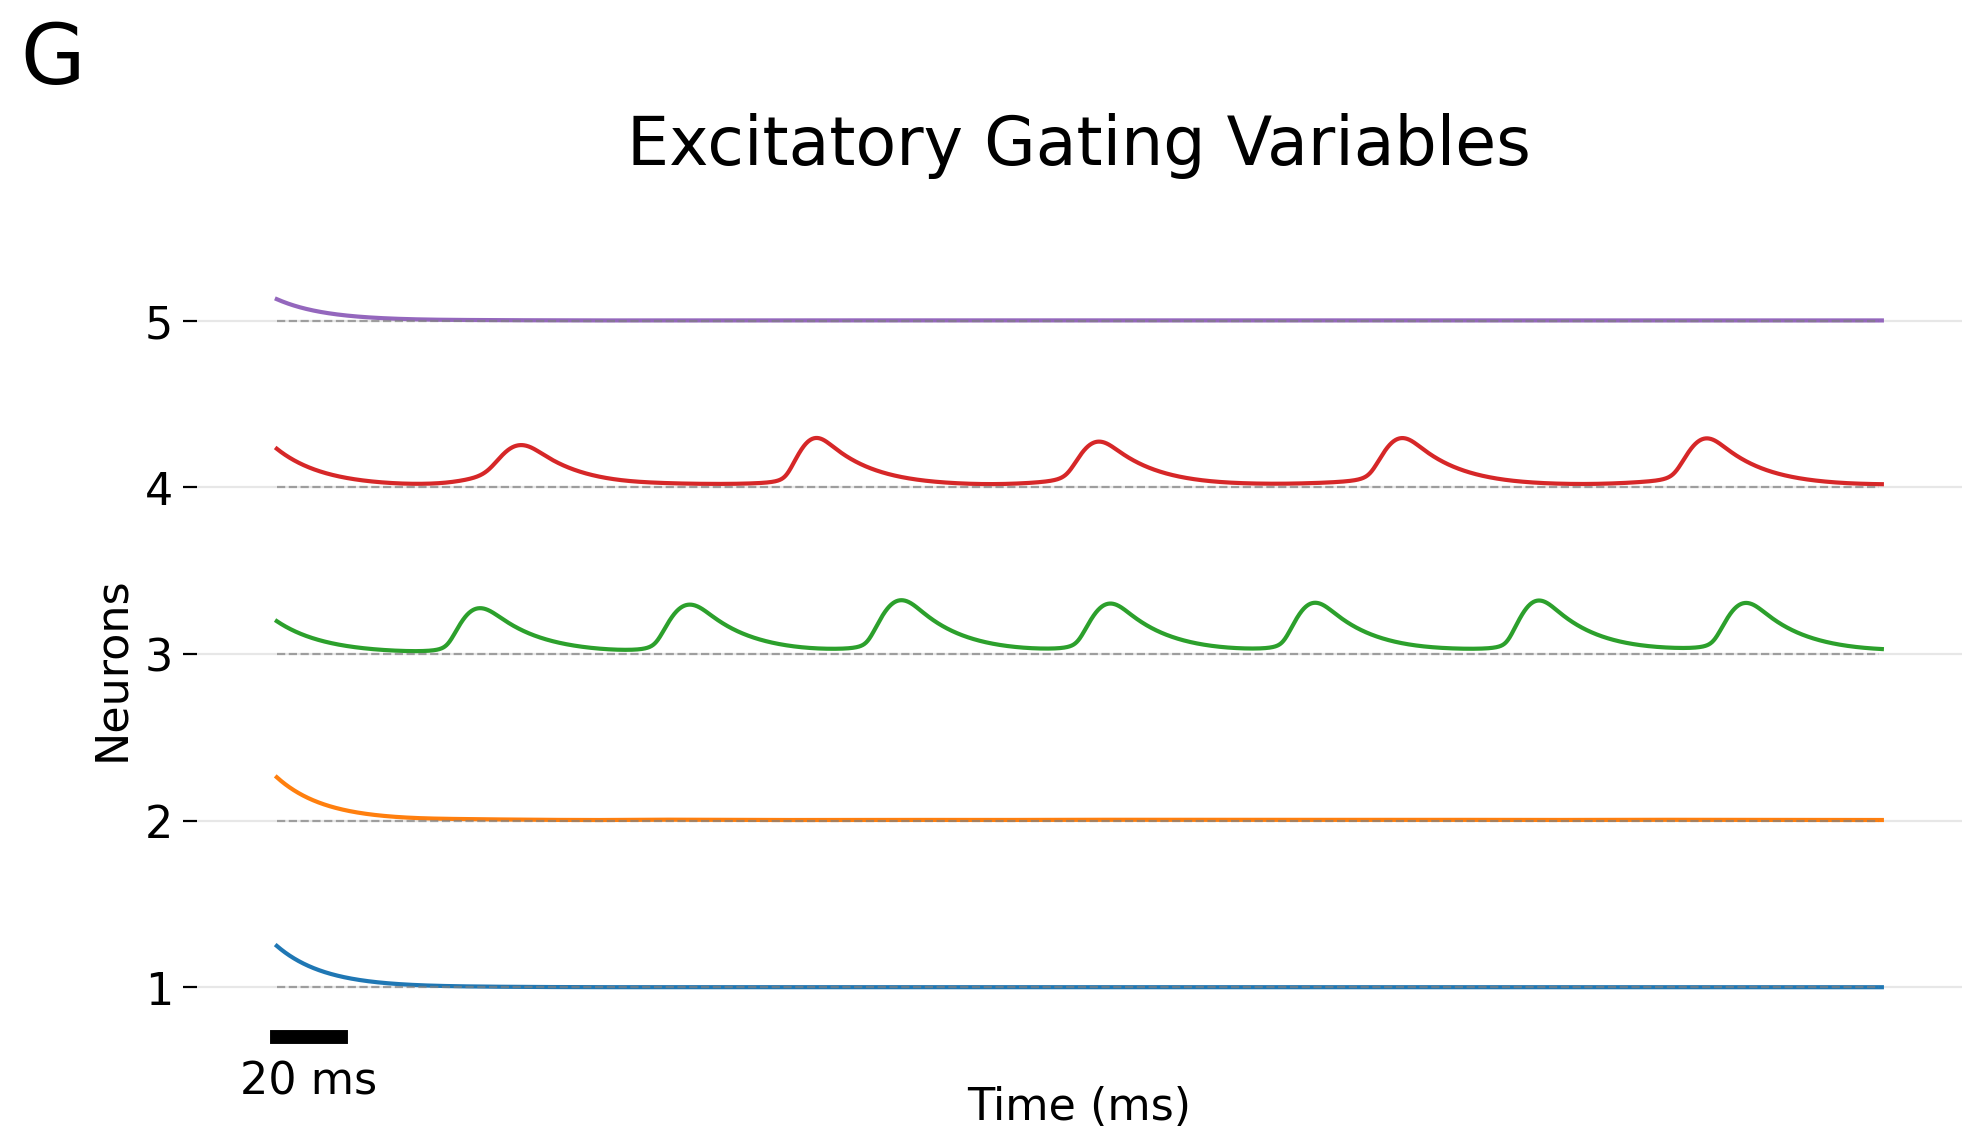

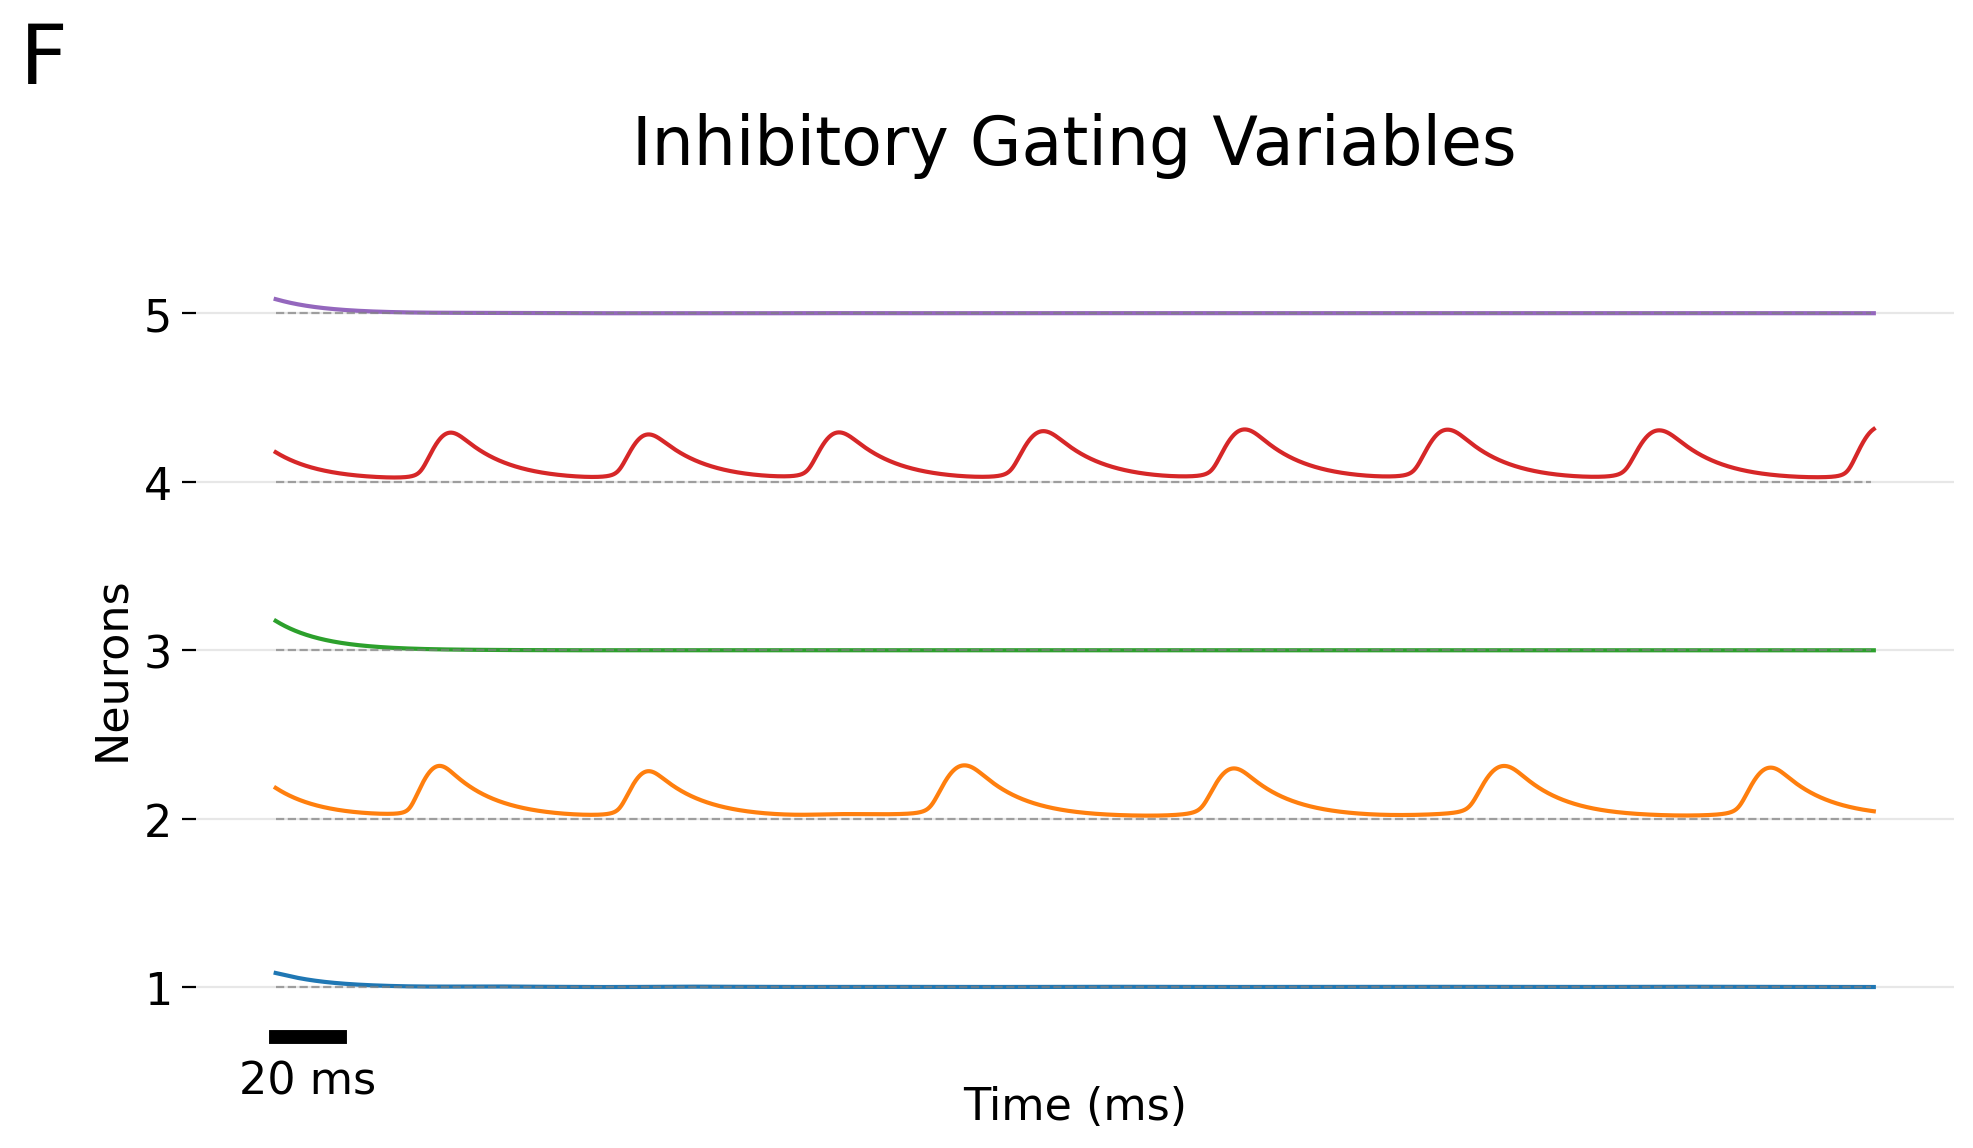

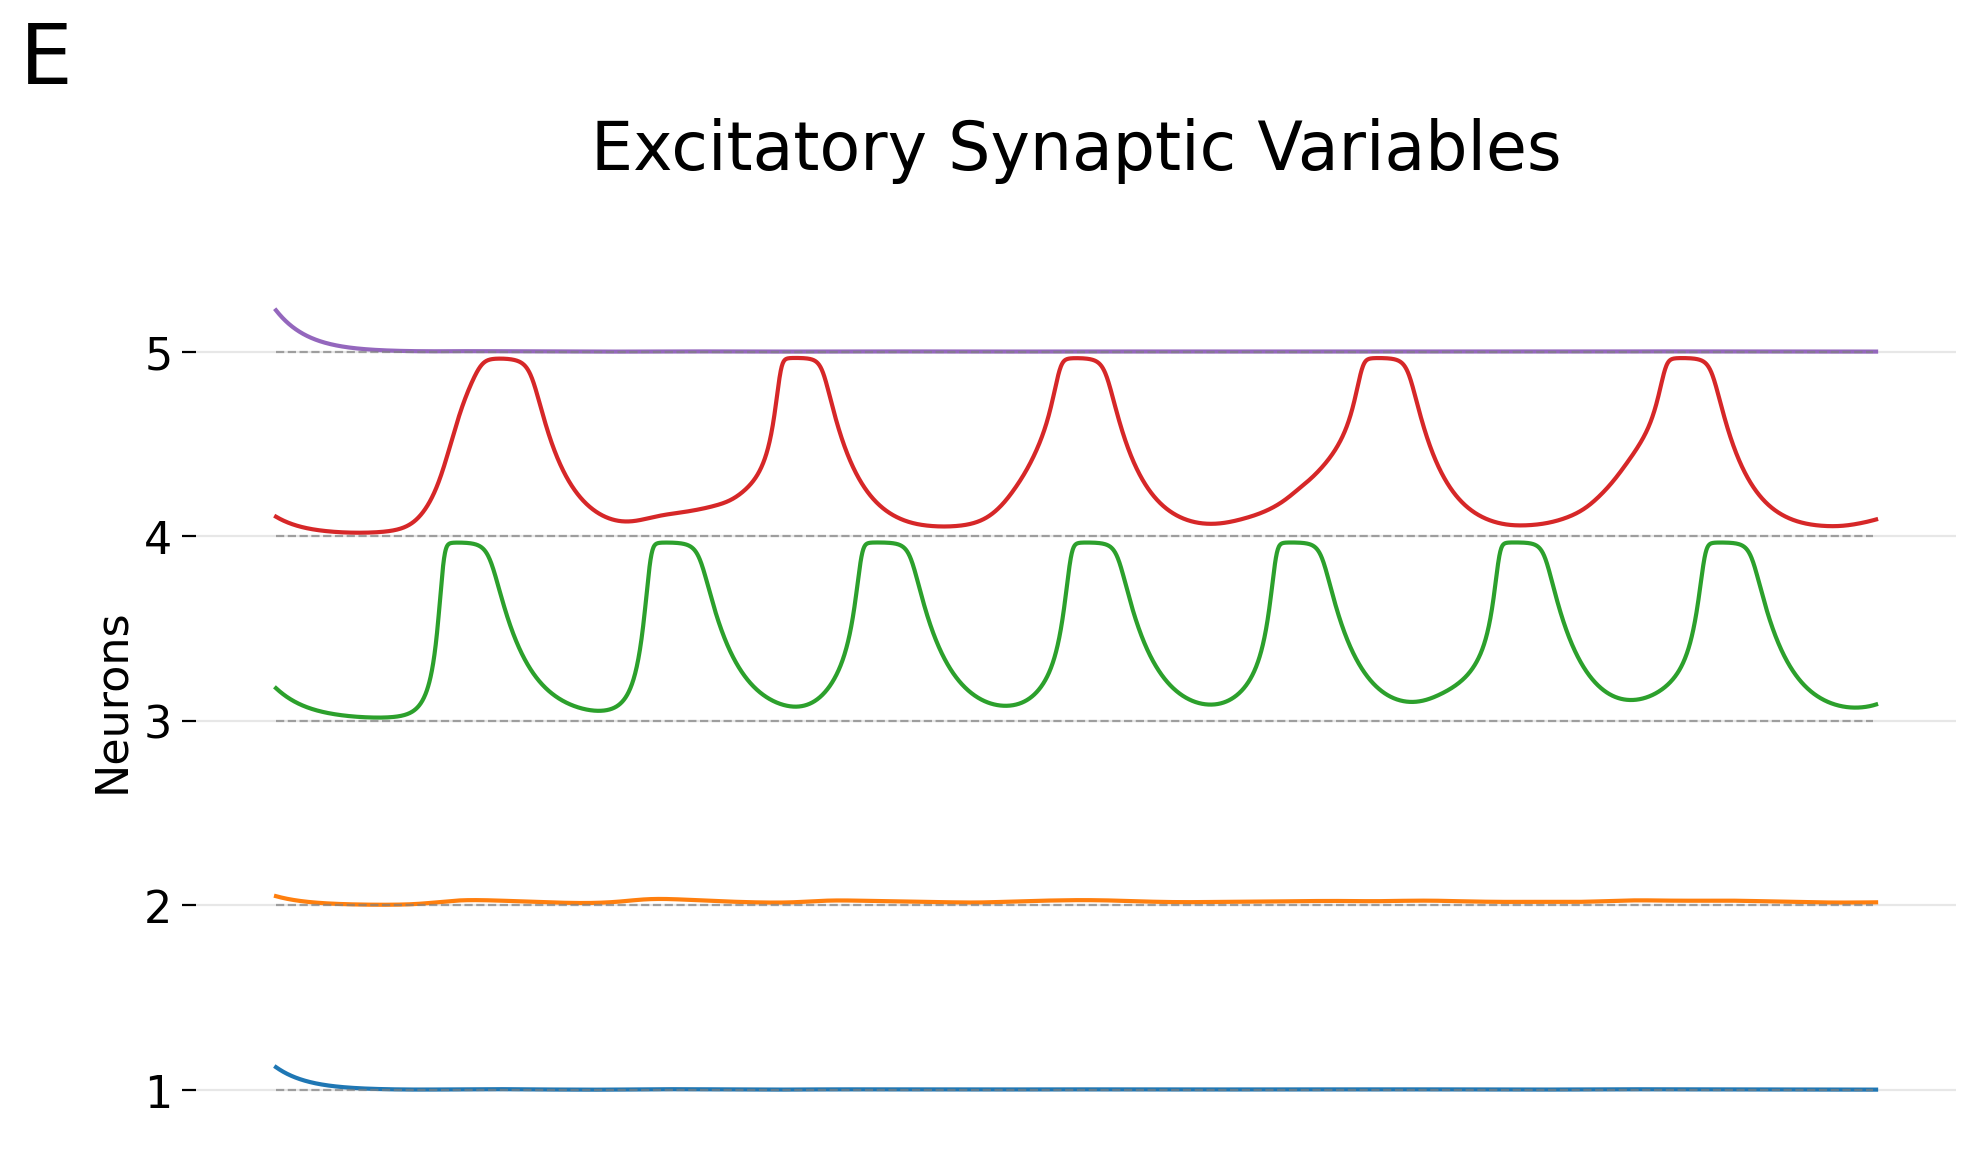

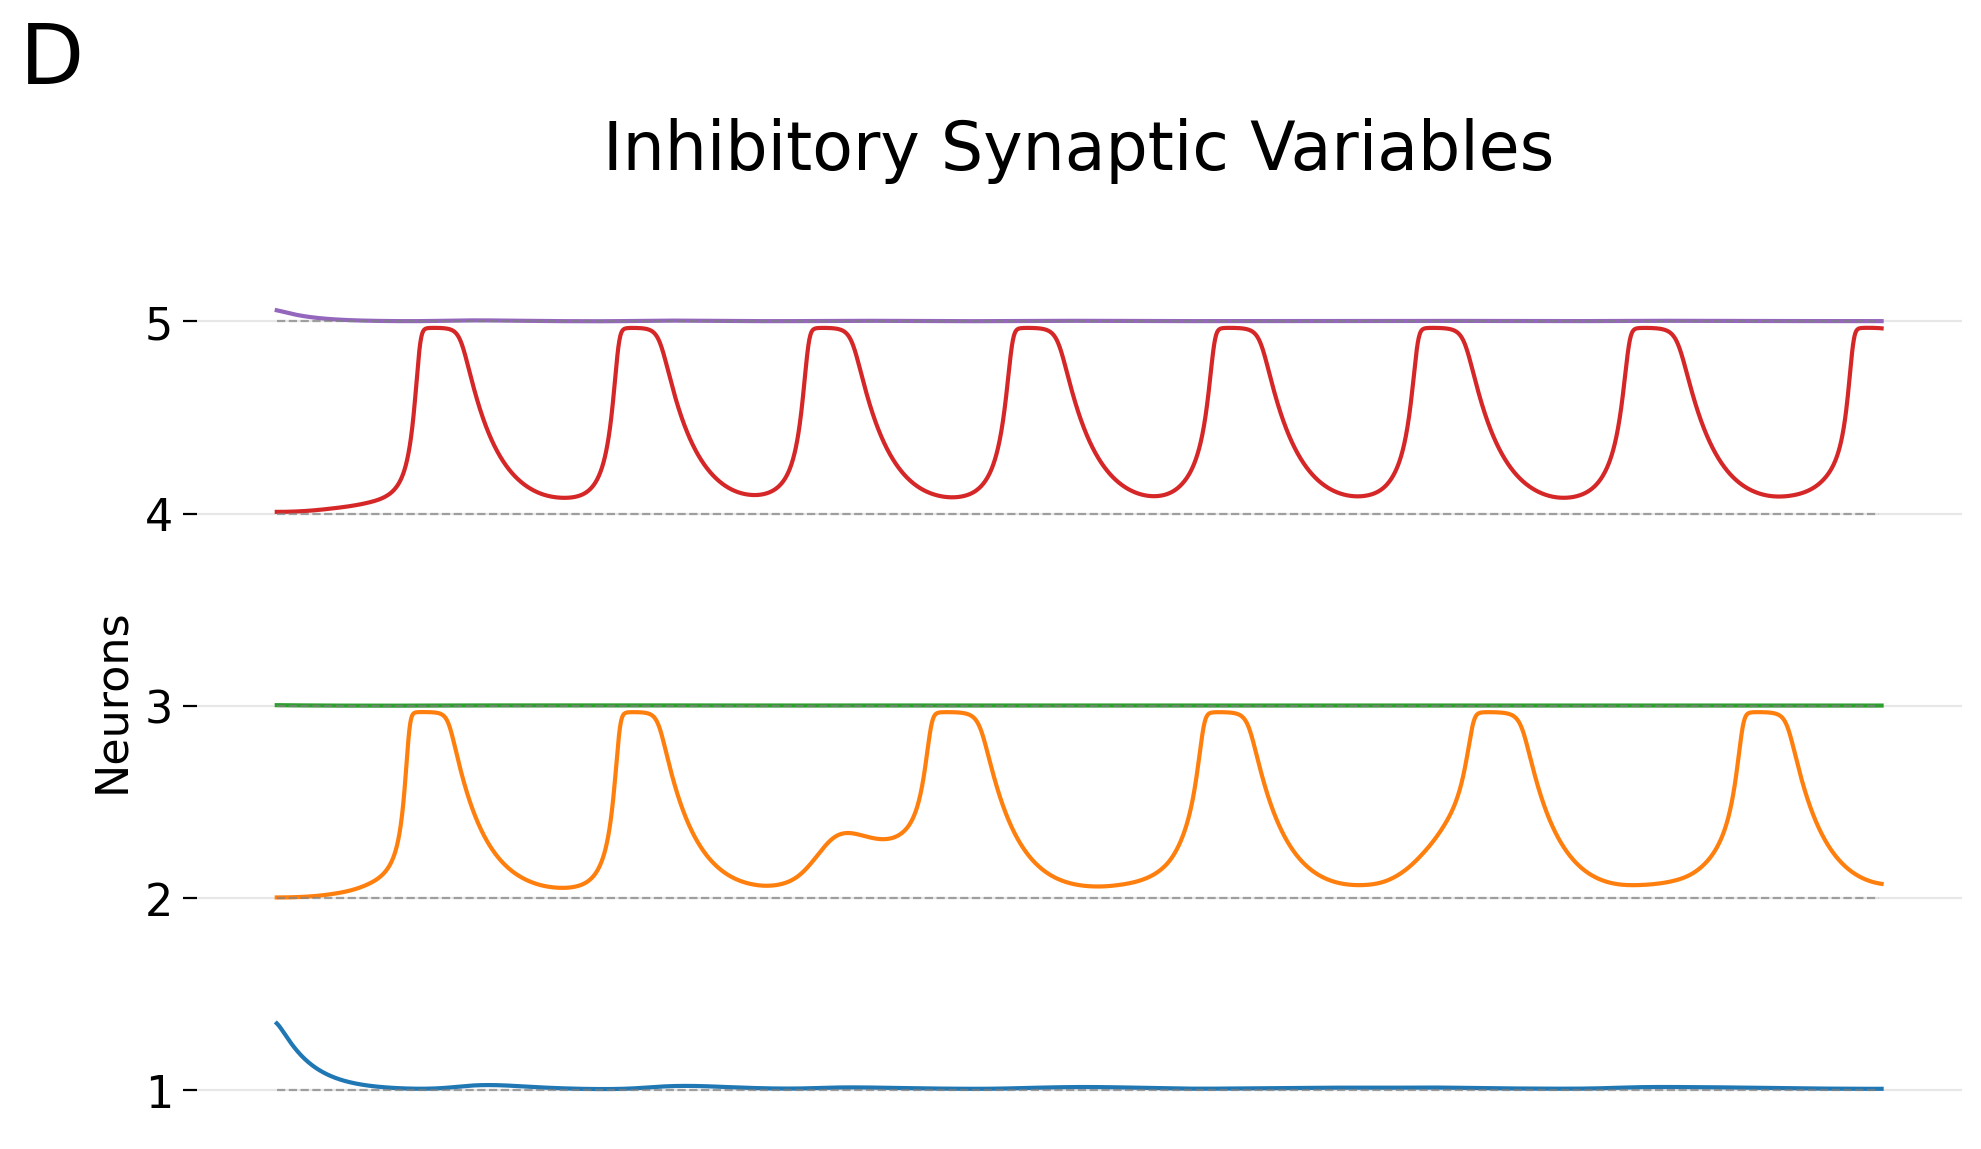

In [13]:
data = {
            'V_e': torch.zeros(Y_batch[0].size(0), NE, device=device),
            'n_e': torch.zeros(Y_batch[0].size(0), NE, device=device),
            's_e': torch.zeros(Y_batch[0].size(0), NE, device=device),
            'V_i': torch.zeros(Y_batch[0].size(0), NI, device=device),
            'n_i': torch.zeros(Y_batch[0].size(0), NI, device=device),
            's_i': torch.zeros(Y_batch[0].size(0), NI, device=device)
        }

data = model.get_storage()
savePlot_full_state(data, 5, 1, "Regression Task")

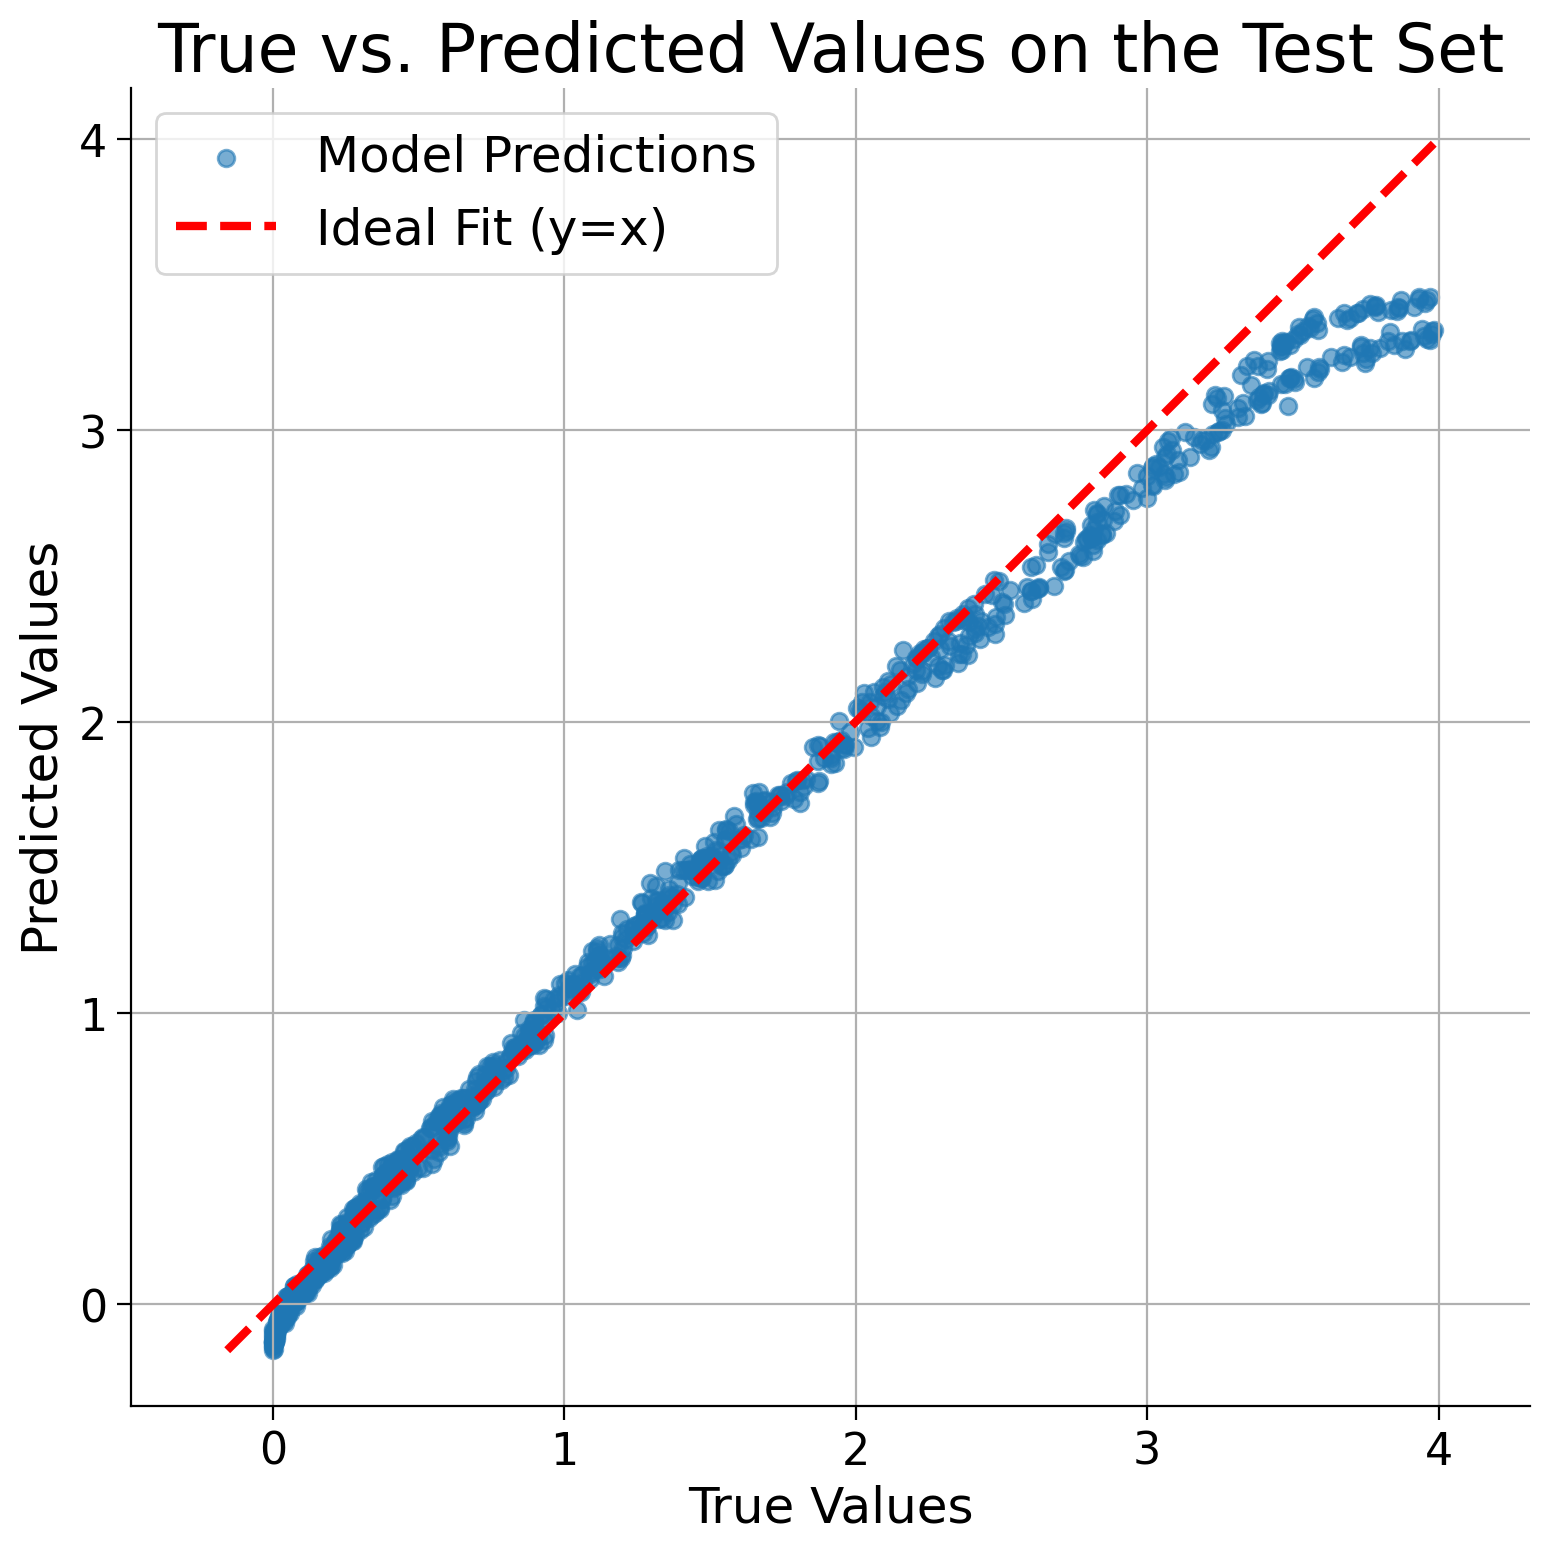

In [14]:
plt.figure(figsize=(8, 8))

plt.scatter(all_targets, all_preds, alpha=0.6, label='Model Predictions')

min_val = min(min(all_targets), min(all_preds))
max_val = max(max(all_targets), max(all_preds))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit (y=x)')

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs. Predicted Values on the Test Set")
plt.legend()
plt.grid(True)

plt.axis('equal')
plt.tight_layout()
plt.show()

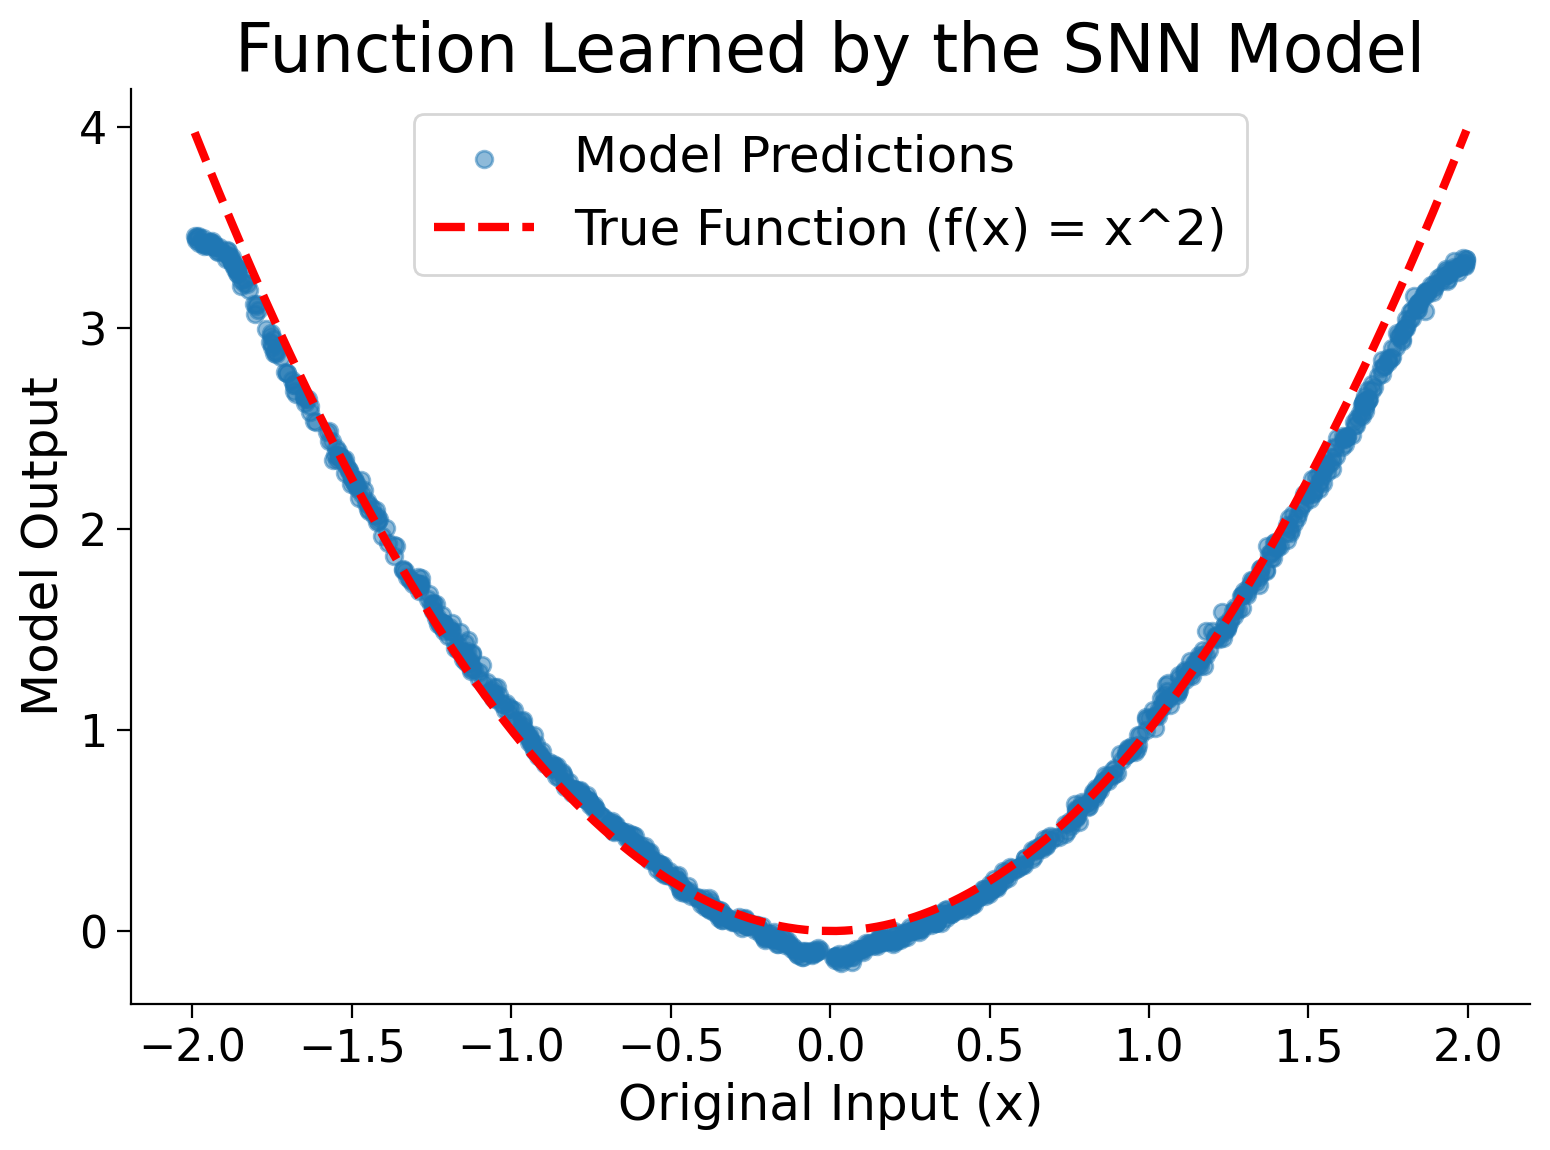

In [15]:
all_inputs = []
with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        all_inputs.append(X_batch[:, 0, :].cpu().numpy())

all_inputs = np.concatenate(all_inputs).flatten()

sort_indices = np.argsort(all_inputs)
all_inputs_sorted = all_inputs[sort_indices]
all_preds_sorted = all_preds[sort_indices]

plt.figure(figsize=(8, 6))

plt.scatter(all_inputs_sorted, all_preds_sorted, label='Model Predictions', alpha=0.5)

plt.plot(all_inputs_sorted, all_inputs_sorted**2, color='red', linestyle='--', label='True Function (f(x) = x^2)')

plt.xlabel("Original Input (x)")
plt.ylabel("Model Output")
plt.title("Function Learned by the SNN Model")
plt.legend()
plt.savefig('Regression-Learned-function.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

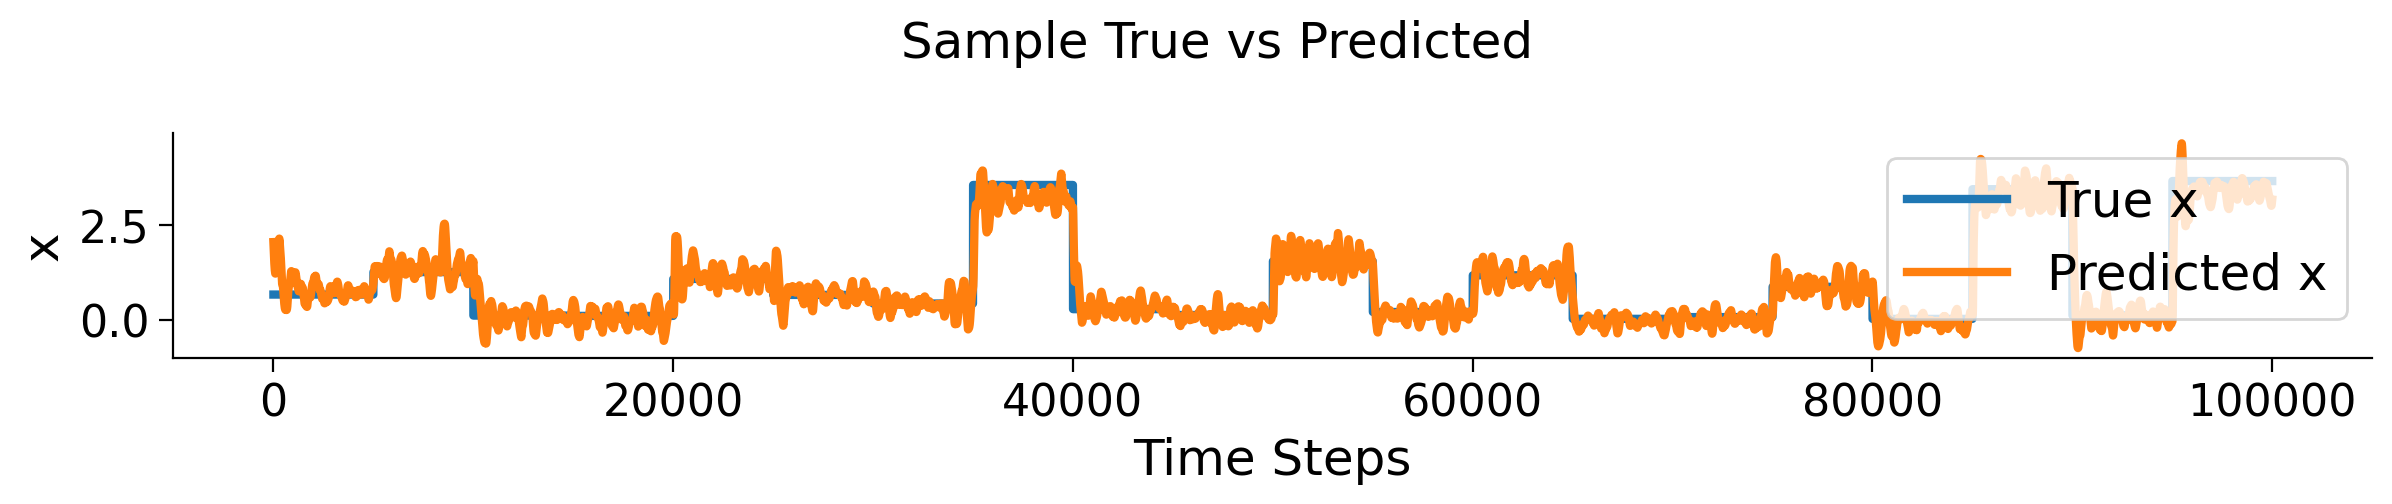

Avg Time-Distributed MSE Loss: 134.281405
Avg Scalar Prediction MAE: 1.266172 (Mean Absolute Error)
R-squared (R²) Score on the Test Set: -0.7089


In [16]:
np.random.seed(1)
torch.manual_seed(1)

model.eval()
test_loss = 0.0
test_abs_error = 0.0
total_samples = 0

all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)
        X_batch = X_batch.view(10, -1, 1)
        Y_batch = Y_batch.view(10, -1, 1)
        signal_len = Y_batch.size(1)
        states = None 
        outputs_list = []  
        
        with torch.no_grad():
            states = model.warmup(torch.zeros(Y_batch.size(0), 1).to(device), warmup_duration, states)        
        model.enable_storage(Y_batch[0].size(0))
        for start in range(0, signal_len, chunk_size):
            y_chunk = Y_batch[:,start: start+chunk_size,:].to(device)
            input_seq = X_batch[:,start]

            chunk_outputs, states = model(input_seq, states)
            loss = criterion(chunk_outputs, y_chunk)
            test_loss += loss.item() * X_batch.size(0)
            
            outputs_list.append(chunk_outputs.detach())
            if states is not None:
                states = tuple(s.detach() for s in states)
        
        outputs_list = torch.concatenate(outputs_list, axis = 1)    
        outputs_number = torch.mean(outputs_list[:, -2500:], dim=1)
        
        all_preds.append(outputs_number.cpu().numpy())
        all_targets.append(Y_batch[:, 0, :].cpu().numpy())
        
        test_abs_error += torch.sum(torch.abs(outputs_number - Y_batch[:, 0, :] )).item()
        total_samples += X_batch.size(0)

plot_output(Y_batch.detach().cpu().numpy(), outputs_list[0].cpu().numpy())

avg_test_loss = test_loss / total_samples
avg_test_mae = test_abs_error / total_samples

# Concatenate results from all batches into single arrays
all_targets = np.concatenate(all_targets).flatten()
all_preds = np.concatenate(all_preds).flatten()

# Calculate the R-squared score
r2 = r2_score(all_targets, all_preds)

print(f"Avg Time-Distributed MSE Loss: {avg_test_loss:.6f}")
print(f"Avg Scalar Prediction MAE: {avg_test_mae:.6f} (Mean Absolute Error)")
print(f"R-squared (R²) Score on the Test Set: {r2:.4f}")

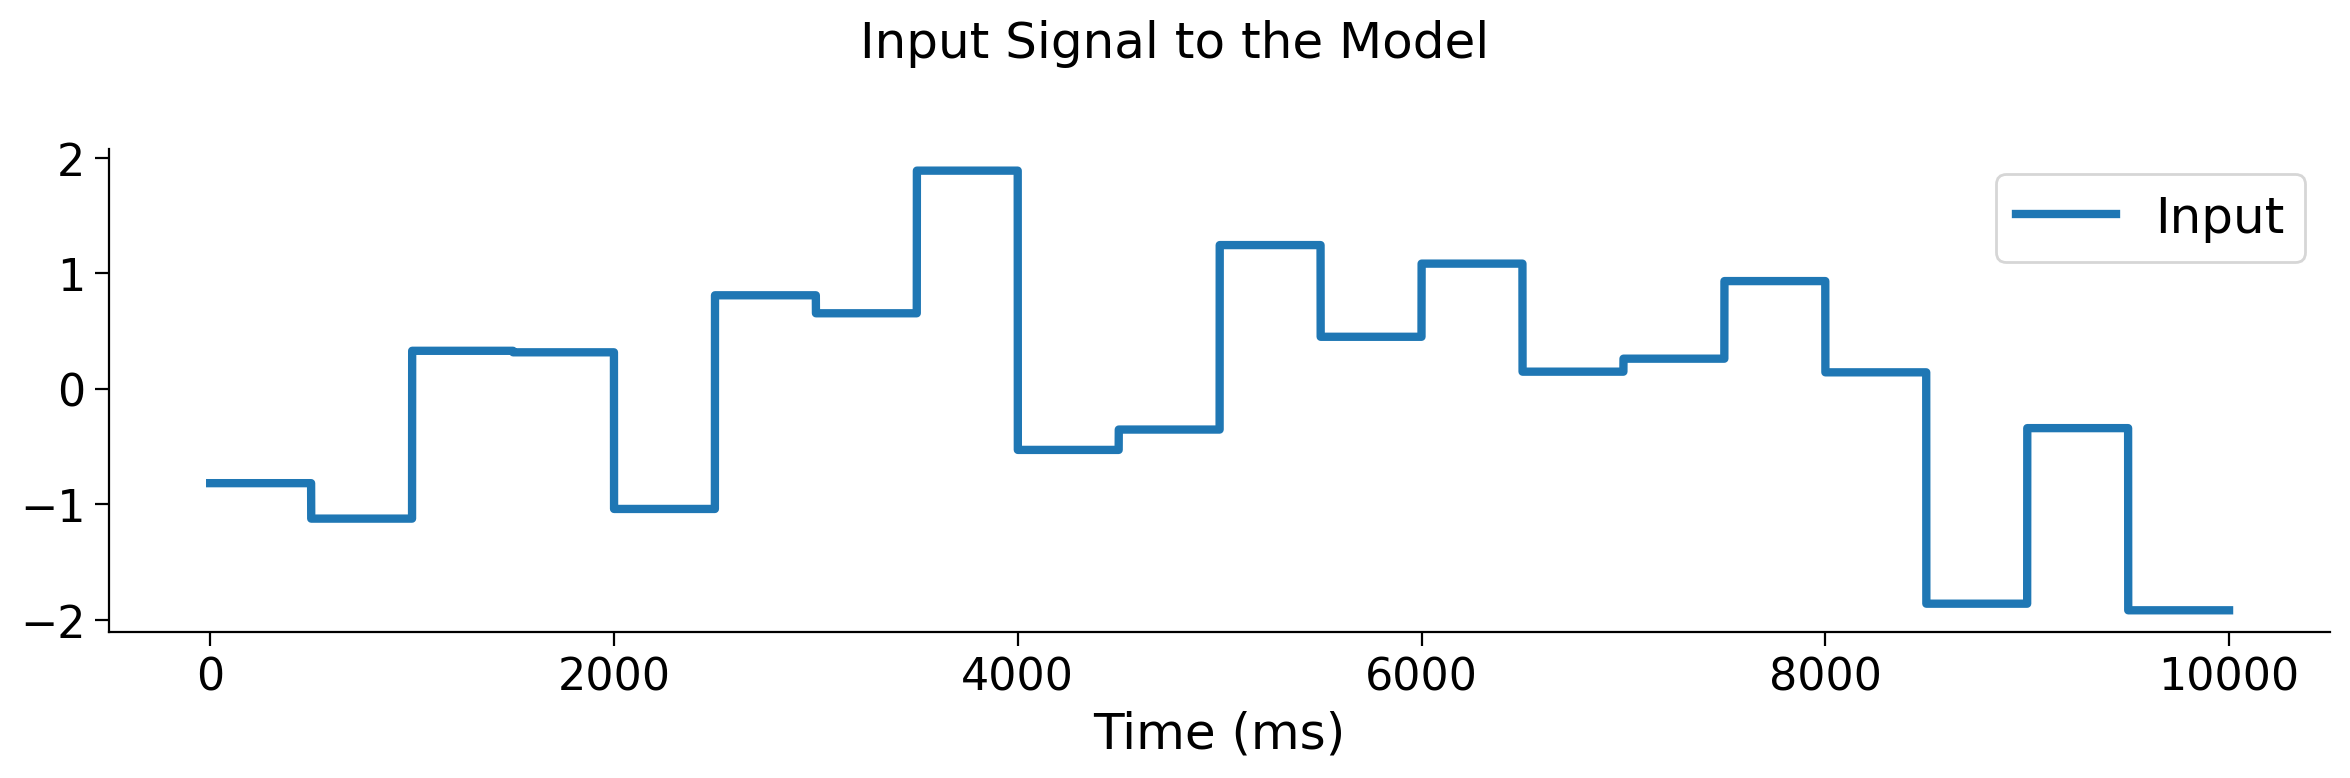

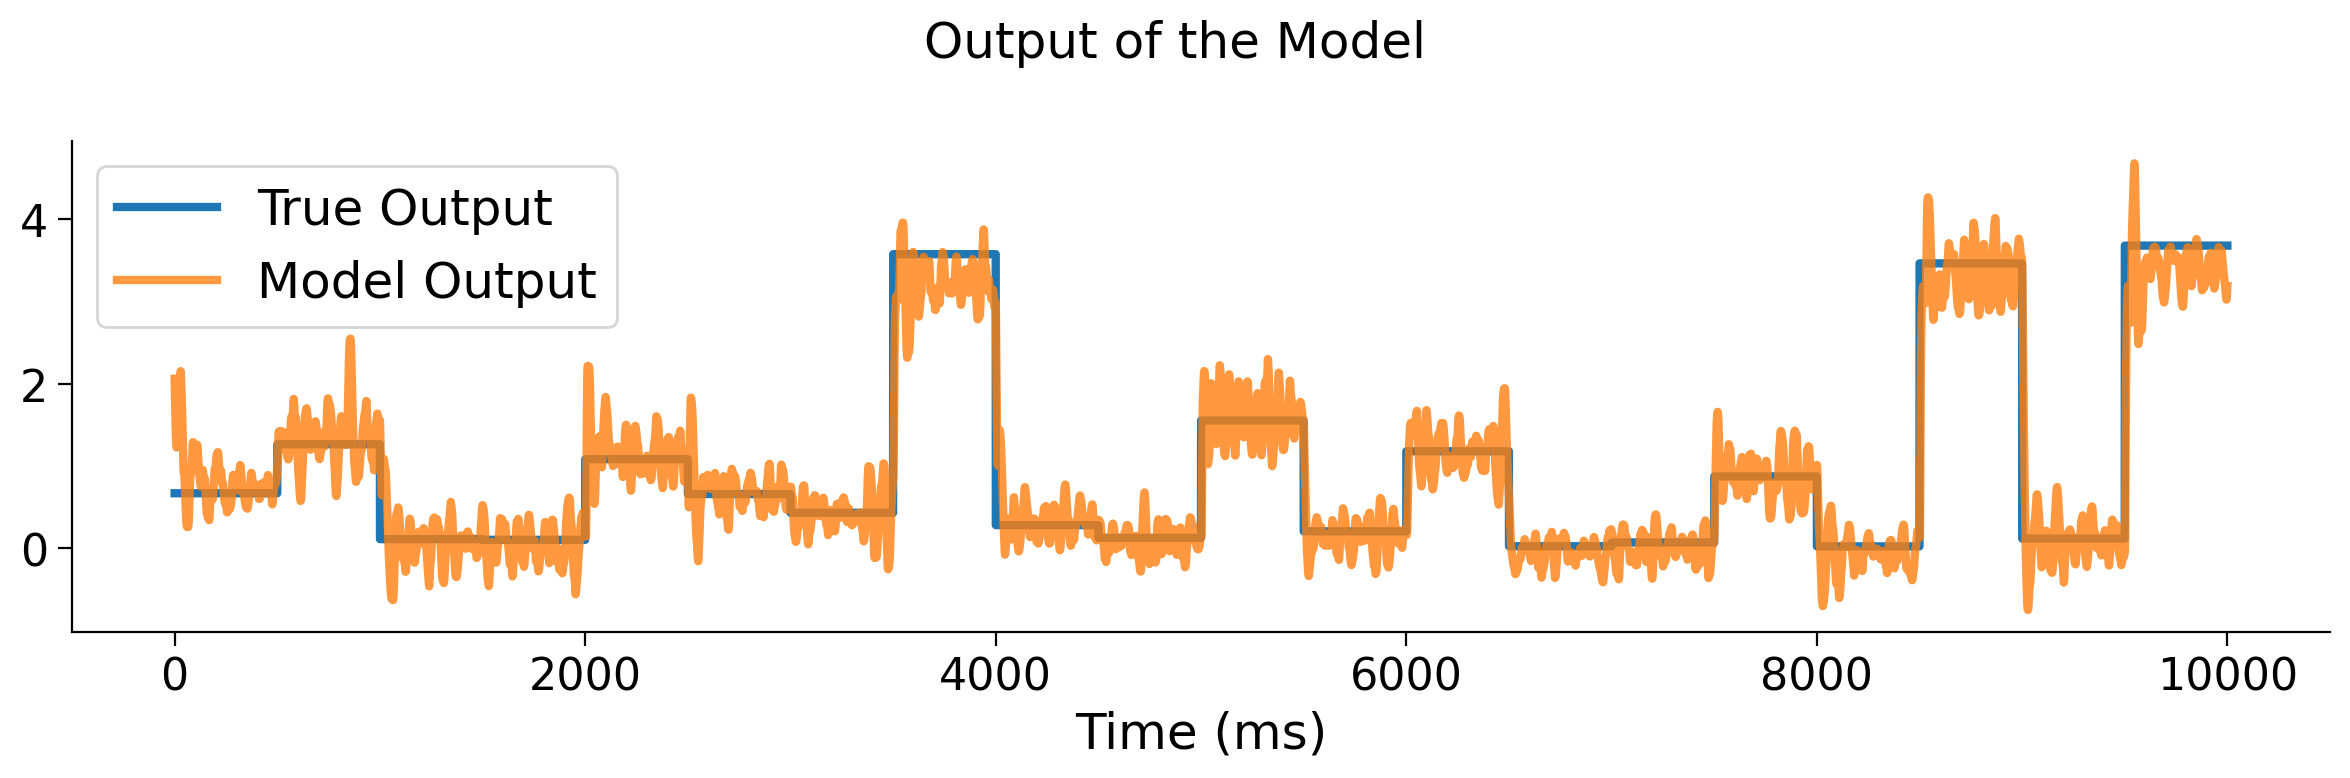

In [17]:
dt = 0.1
generation_len = Y_batch[0].size(0)
plt.figure(figsize=(12, 4))
plt.plot(np.arange(0, generation_len) * dt, X_batch[0].cpu().numpy(), label=f"Input")
plt.xlabel('Time (ms)')
plt.legend()
plt.suptitle('Input Signal to the Model')
plt.savefig('Regression-model-input-sequence.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(np.arange(0, generation_len) * dt, Y_batch[0].cpu().numpy(), label=f"True Output")
plt.plot(np.arange(0, generation_len) * dt, outputs_list[0].cpu().numpy(), label=f"Model Output", alpha=0.8)

plt.legend()
plt.xlabel('Time (ms)')
plt.suptitle('Output of the Model')
plt.savefig('Regression-model-output-sequence.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

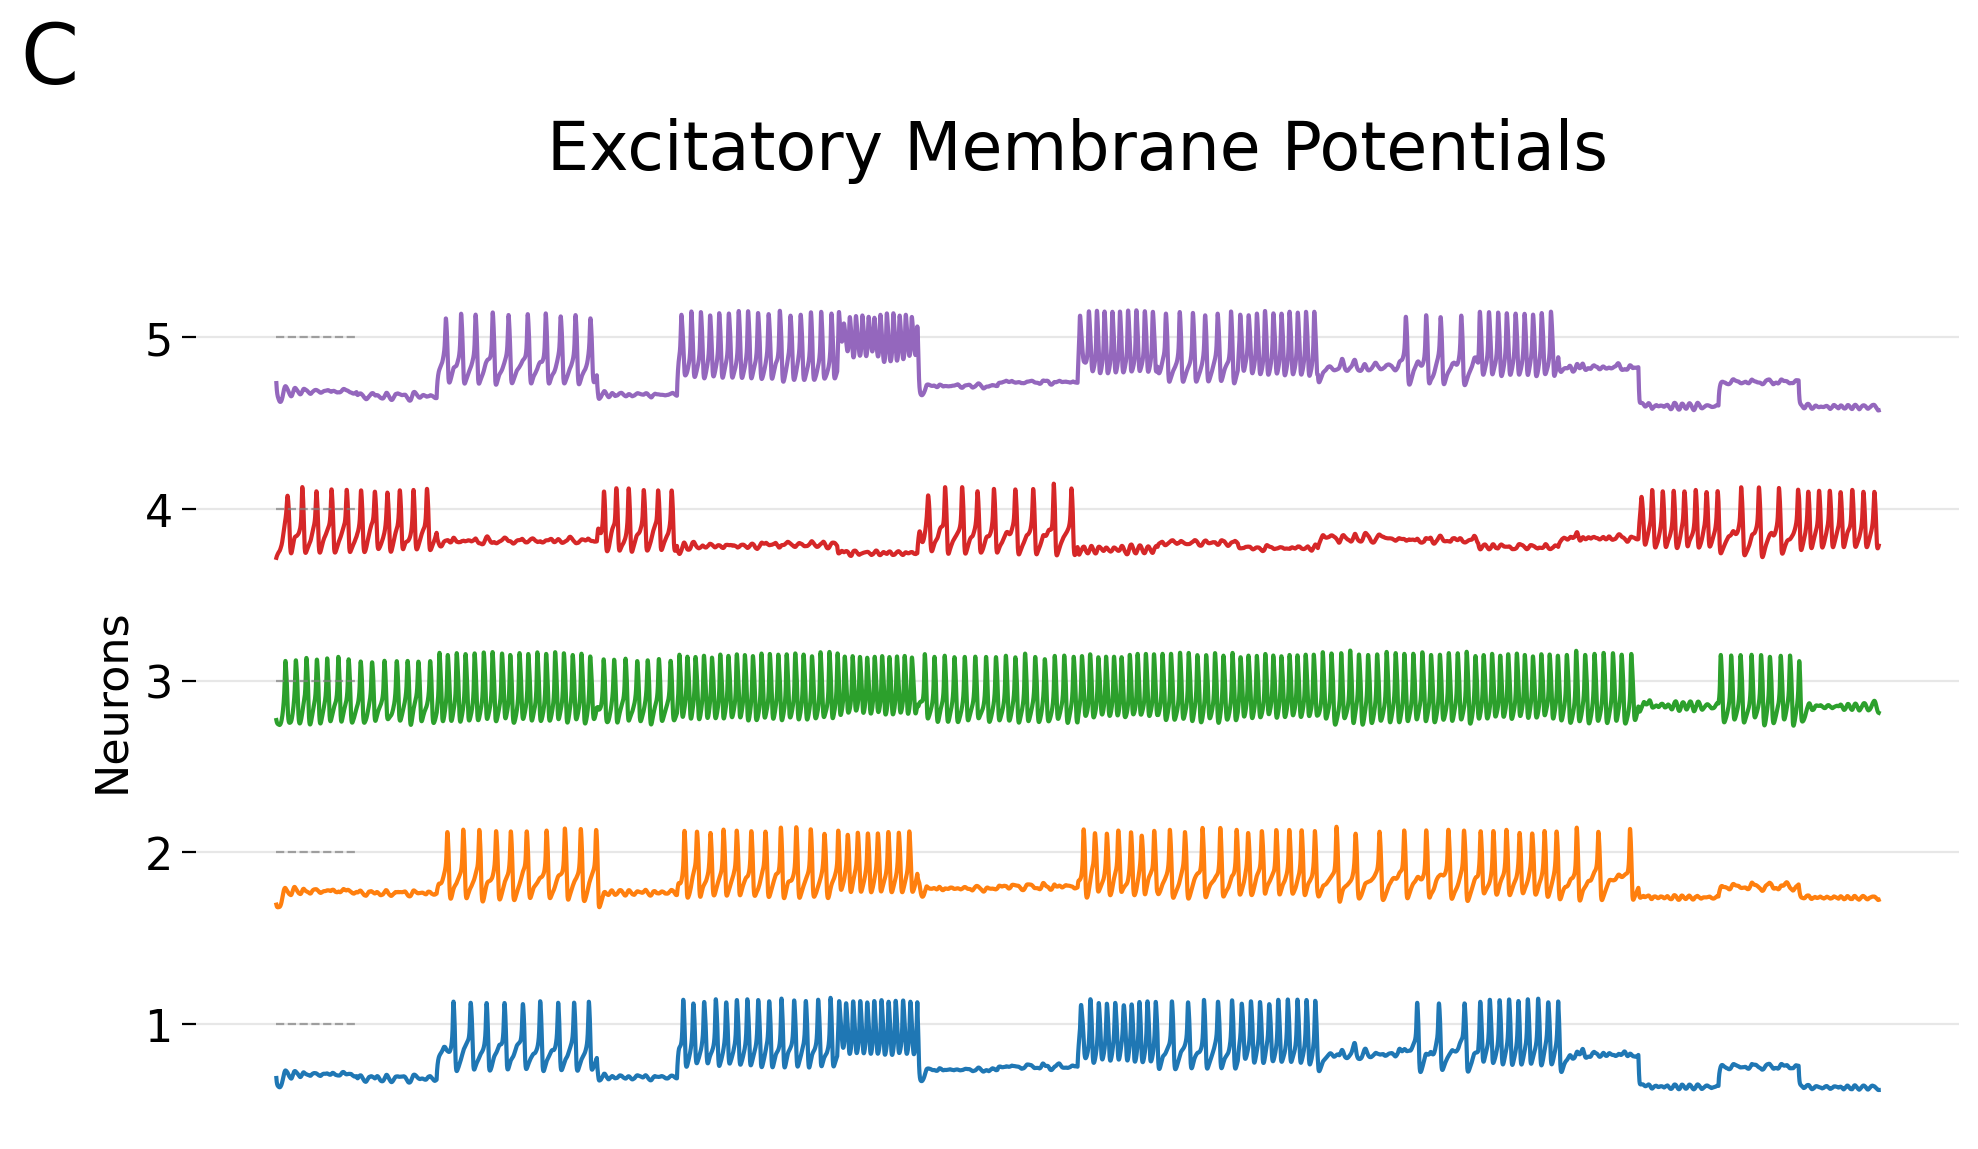

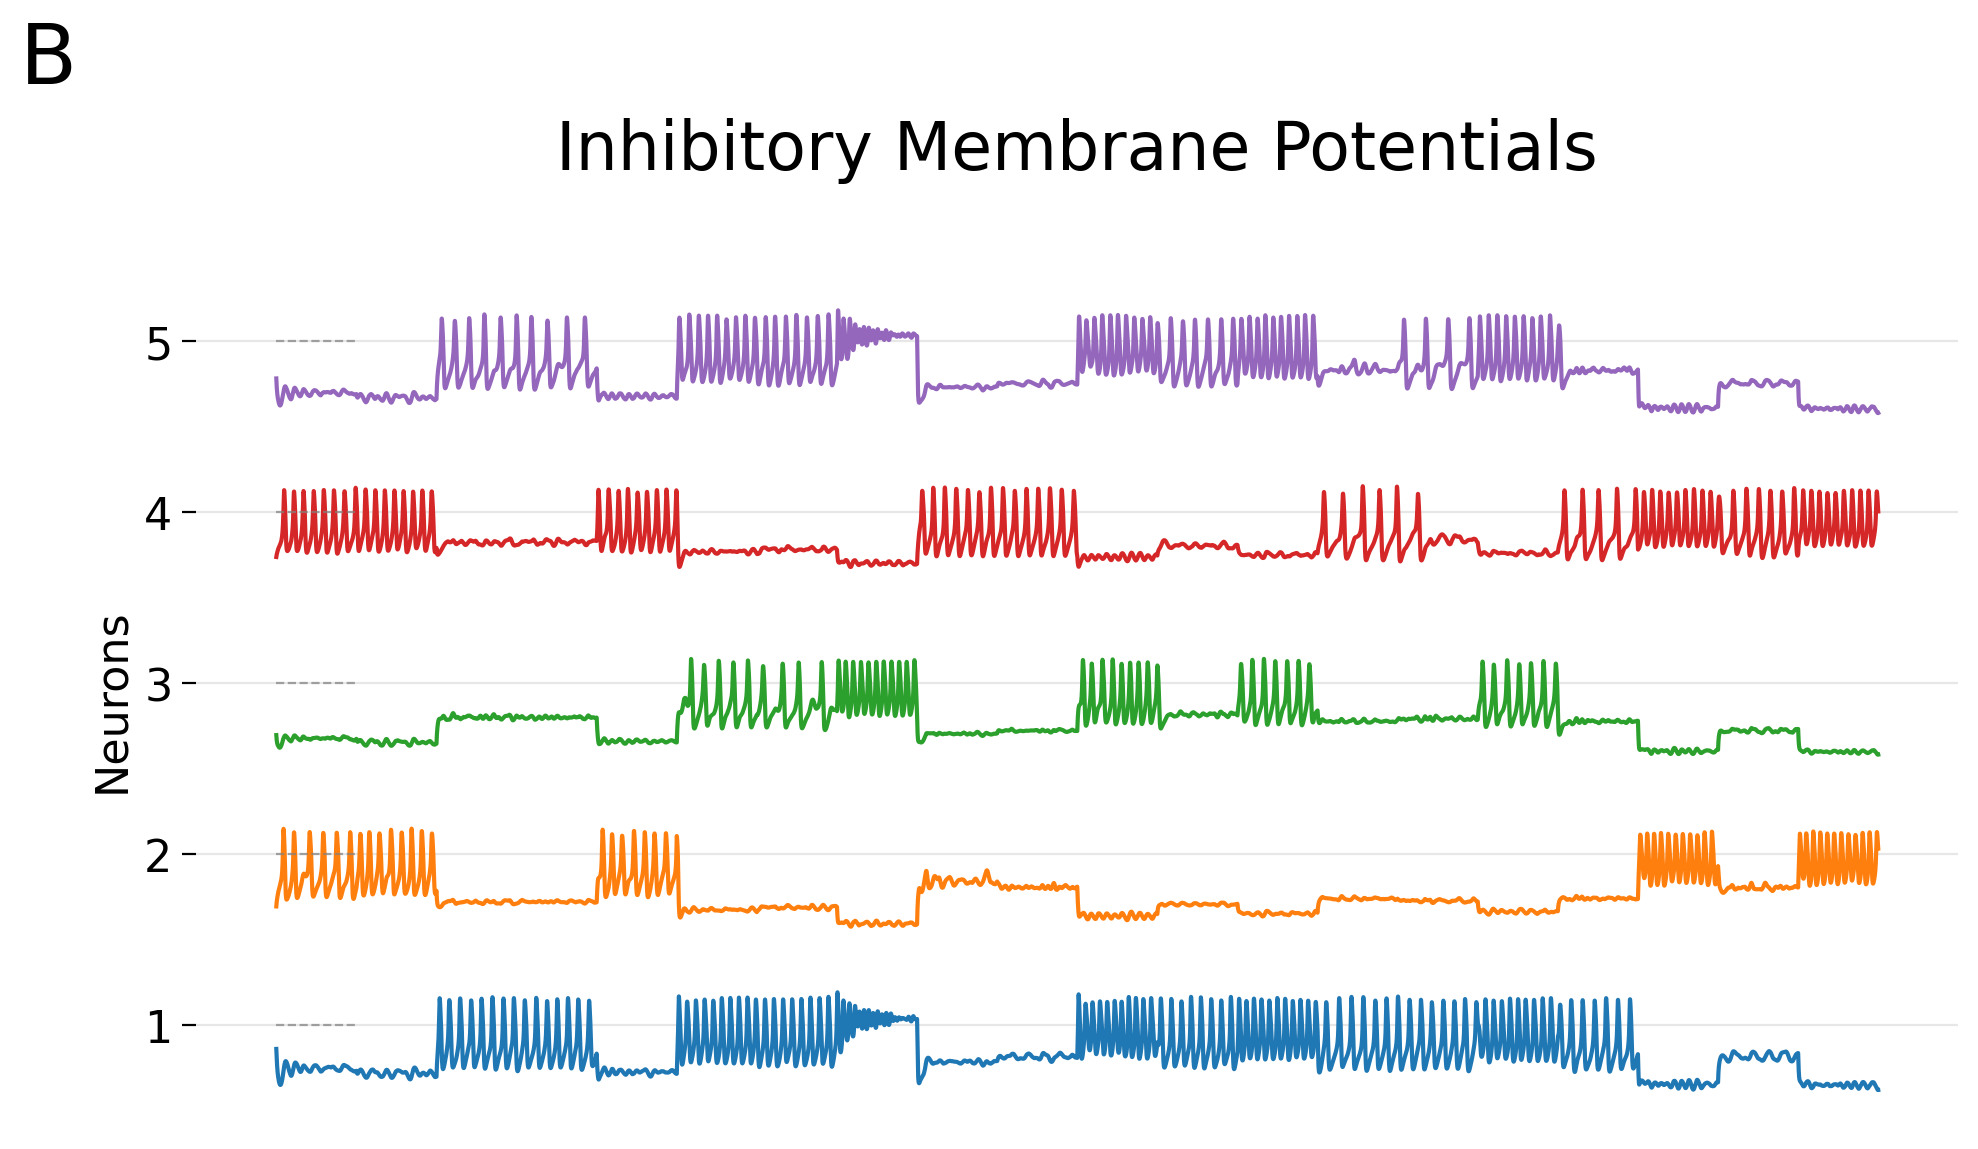

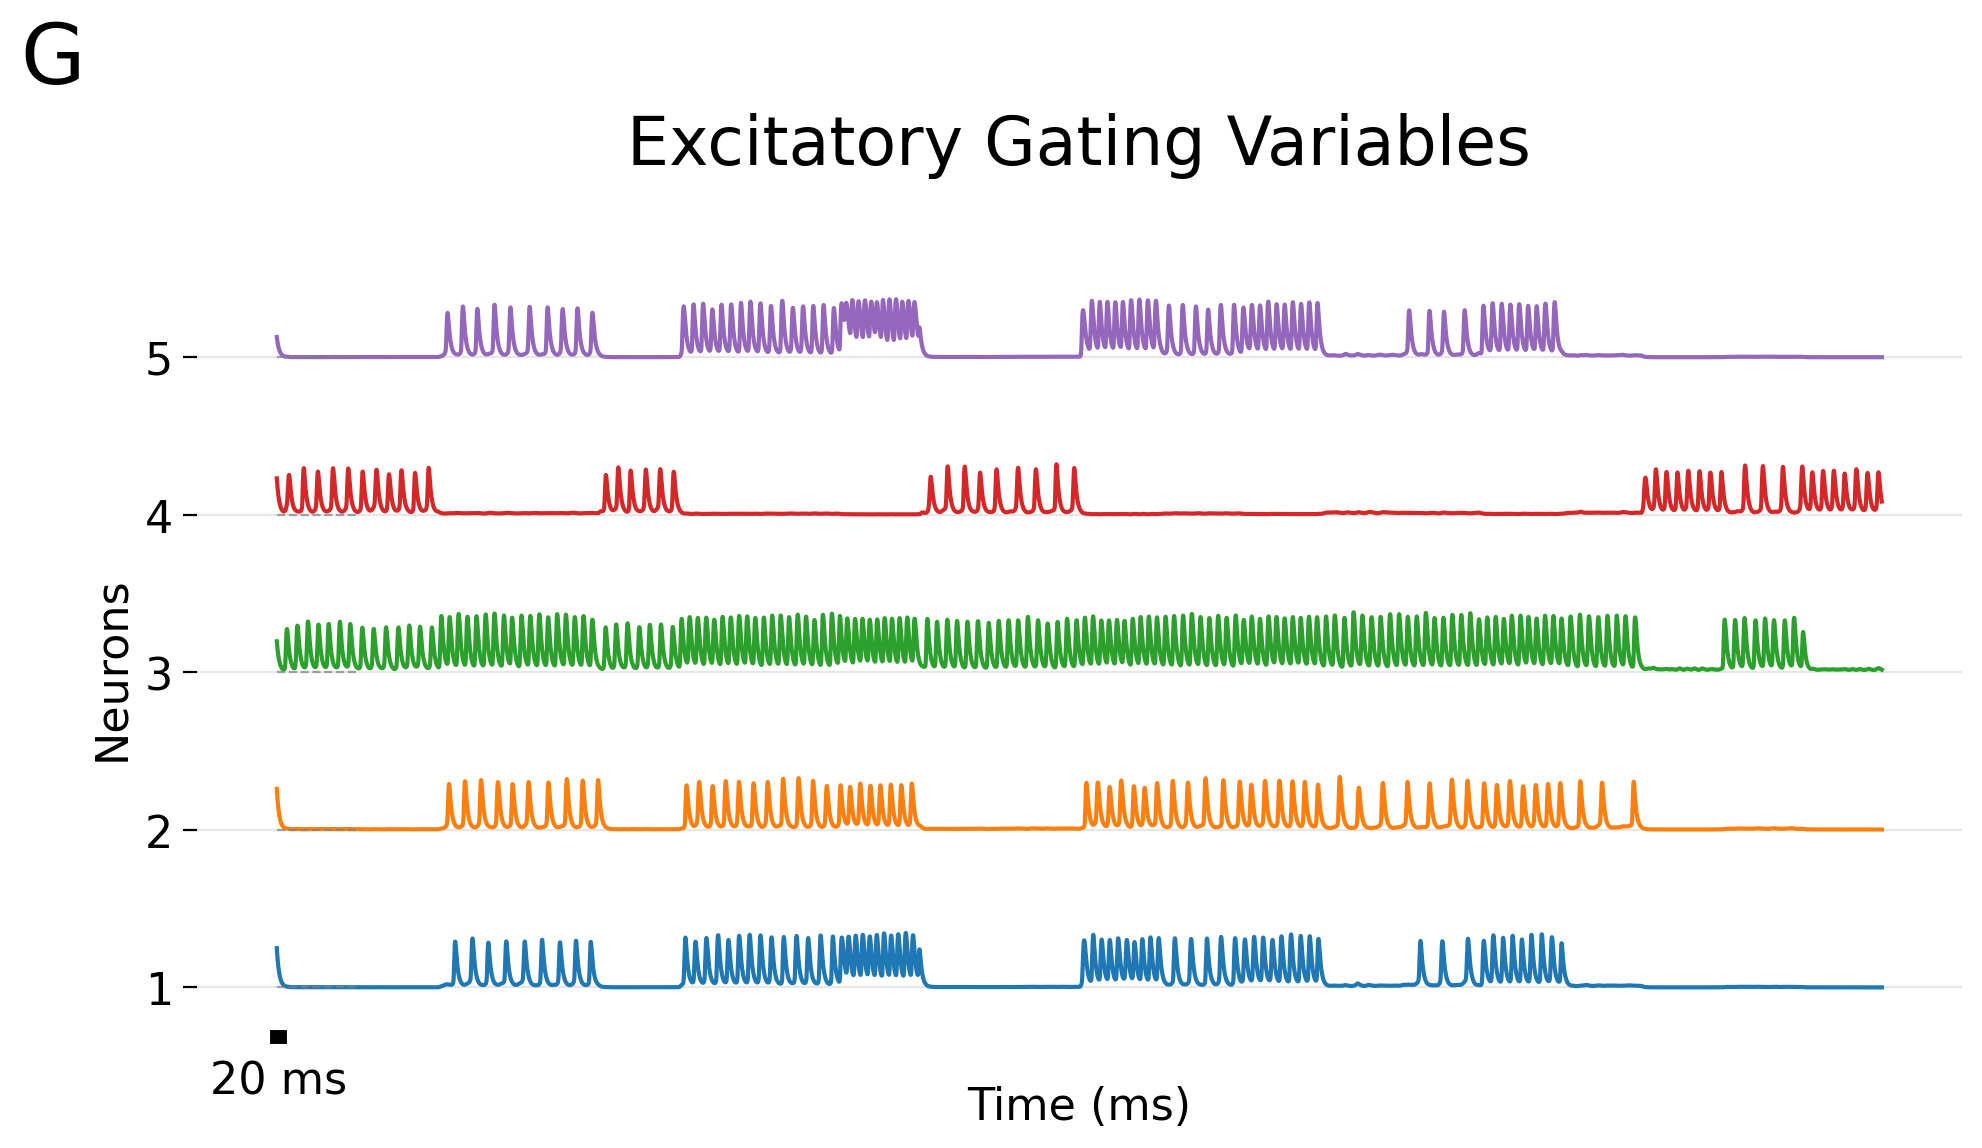

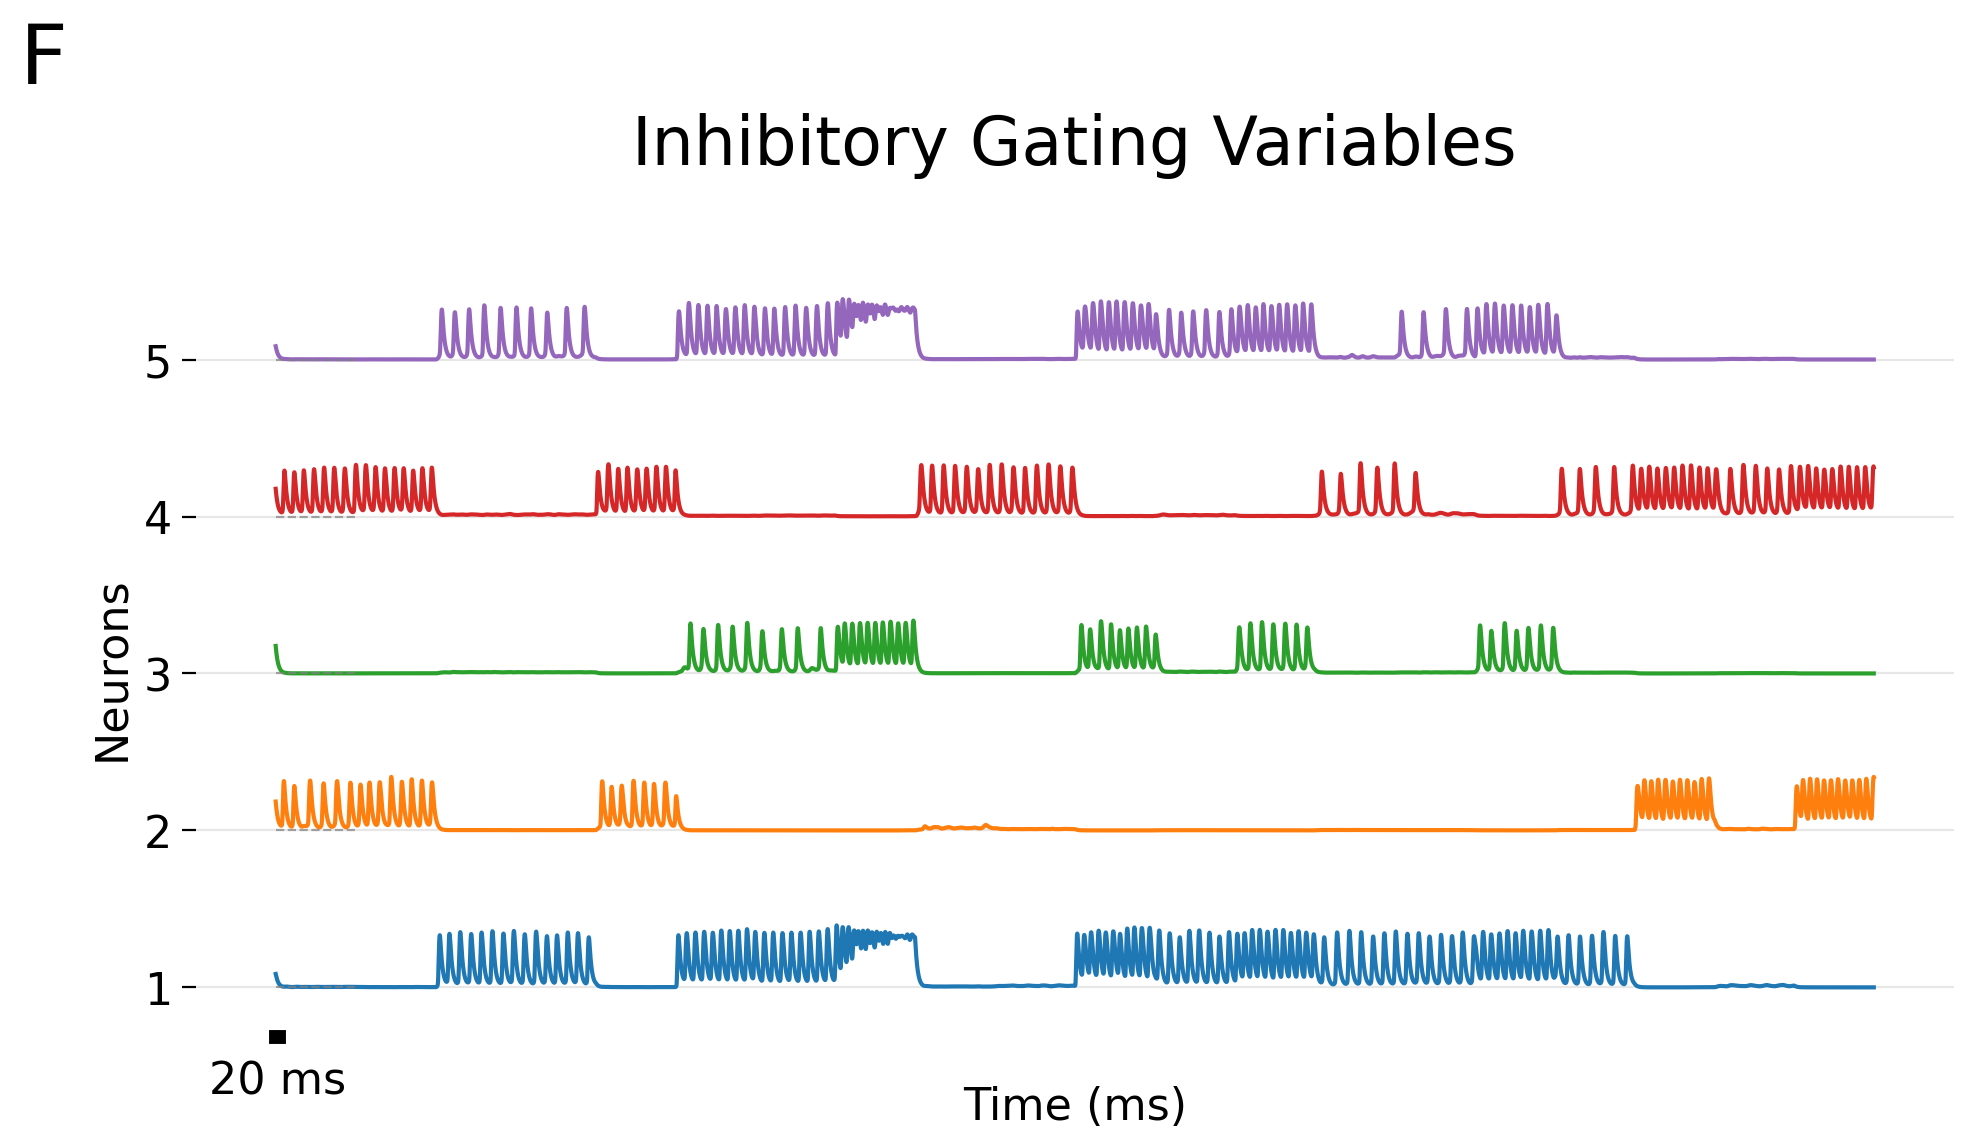

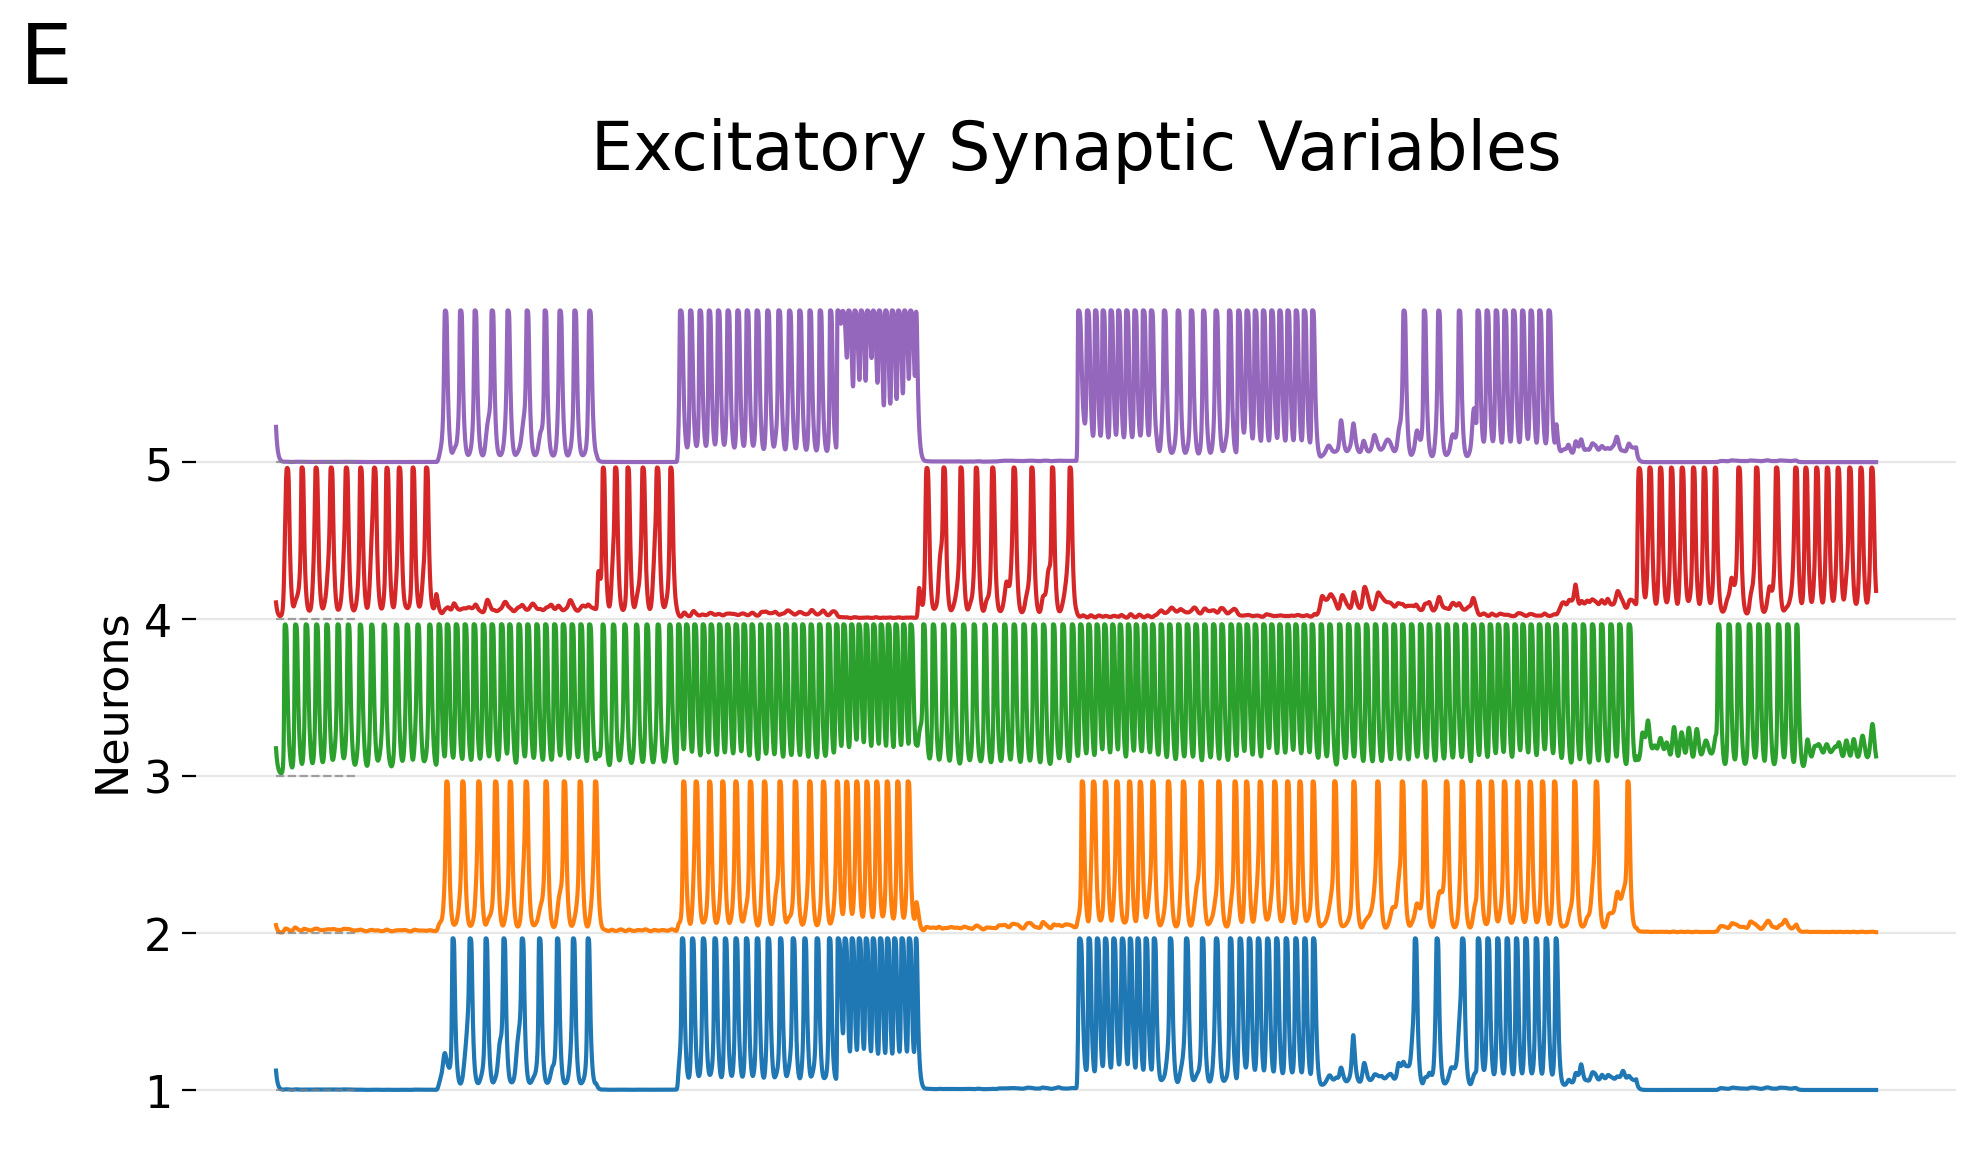

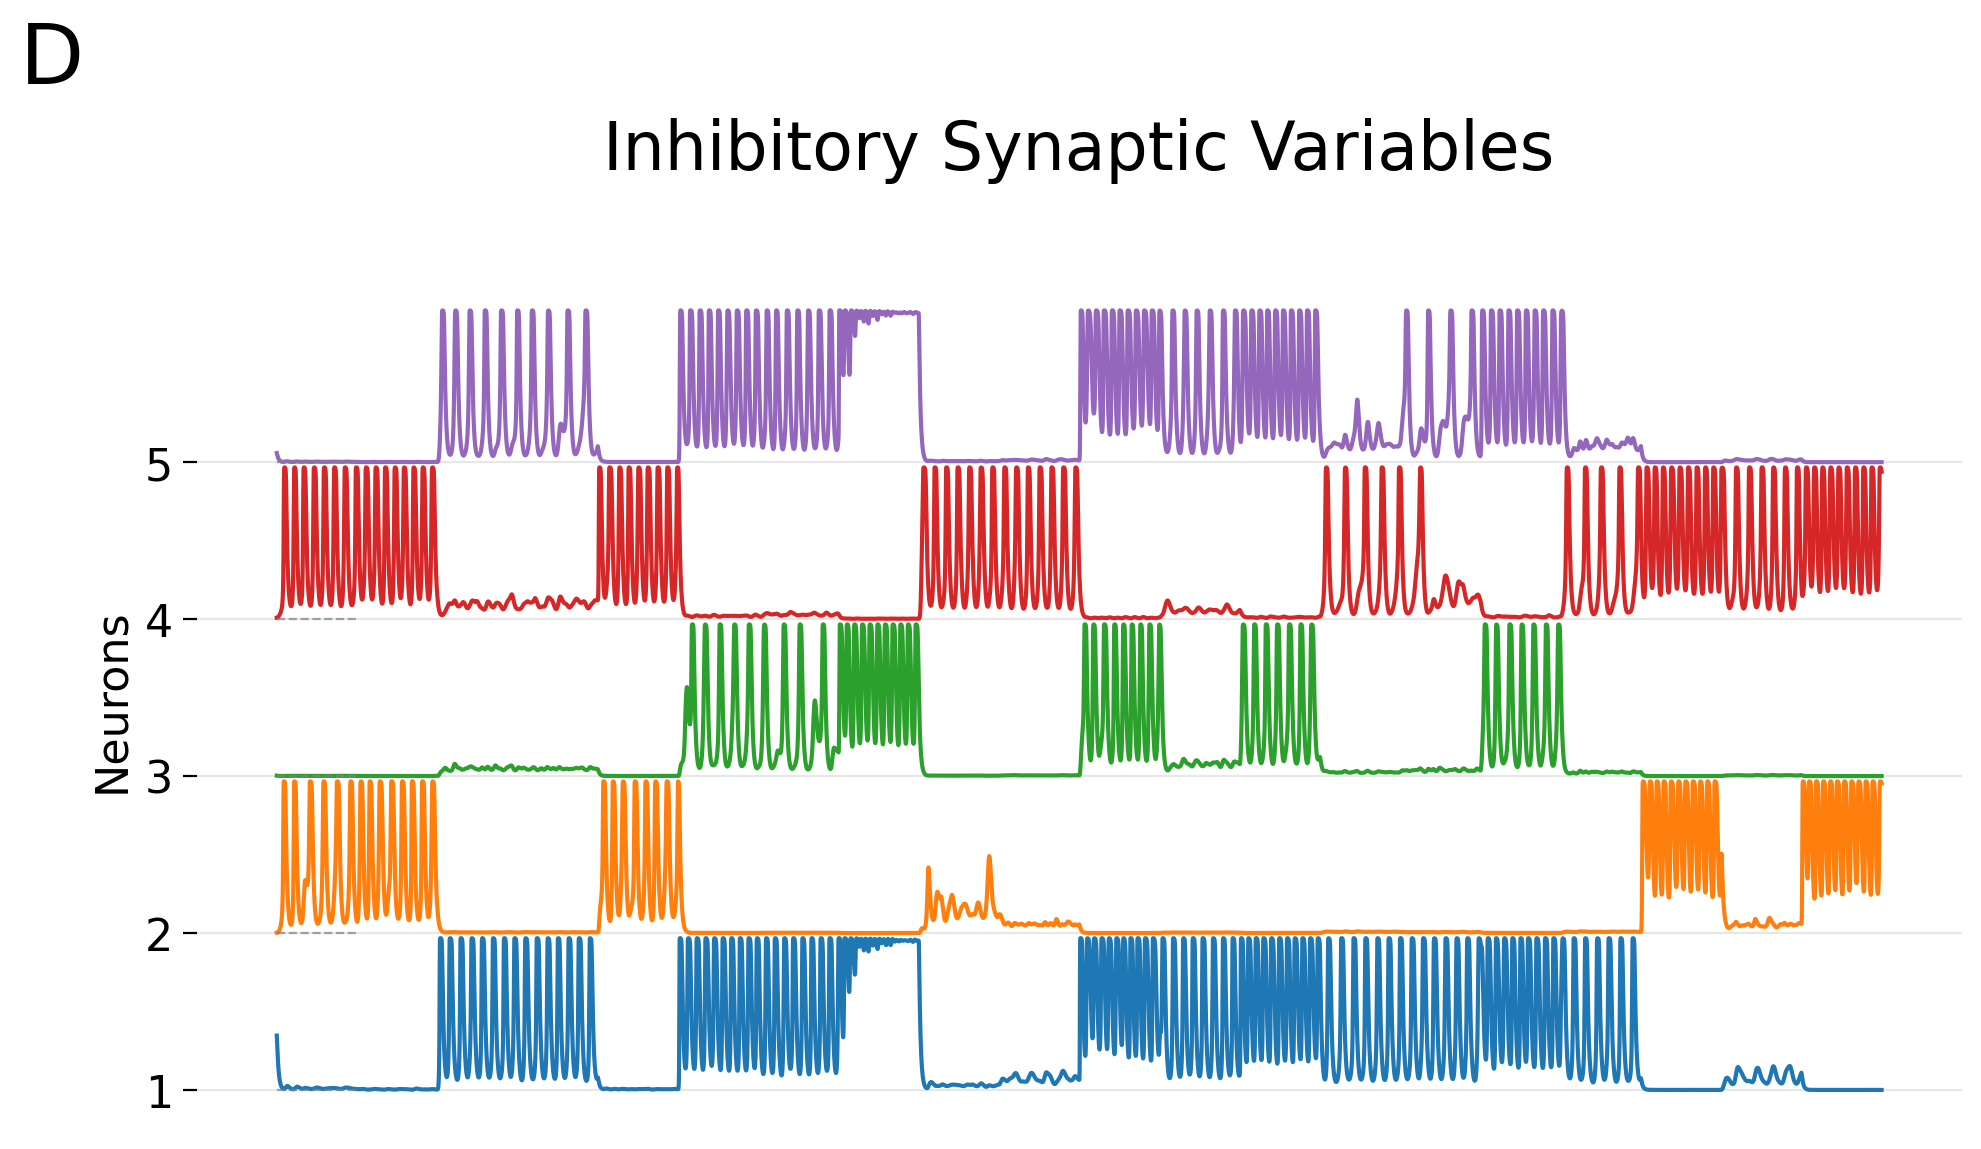

In [18]:
data = {
            'V_e': torch.zeros(Y_batch[0].size(0), NE, device=device),
            'n_e': torch.zeros(Y_batch[0].size(0), NE, device=device),
            's_e': torch.zeros(Y_batch[0].size(0), NE, device=device),
            'V_i': torch.zeros(Y_batch[0].size(0), NI, device=device),
            'n_i': torch.zeros(Y_batch[0].size(0), NI, device=device),
            's_i': torch.zeros(Y_batch[0].size(0), NI, device=device)
        }

data = model.get_storage()
savePlot_full_state(data, 5, 1, "Regression Task Sequential")